# 🏺 Egyptian Hieroglyph Recognition Pipeline — v2 (Fixed + Enhanced)
### Fuentes-Ferrer et al. (2025) — Applied Soft Computing
#### Data Pre-processing → Segmentation (IGSM) → Classification (CVV) → NLP Ready

**Fixes in v2:**
- ✅ `@dataclass` decorator on `SegConfig` (type hints now enforced)
- ✅ `resize_and_pad` saves to separate `Glyph2025_processed/` (no in-place overwrite)
- ✅ `subprocess` used consistently (no more `os.system`)
- ✅ `class_weights` added to `CrossEntropyLoss` for imbalanced classes
- ✅ `sam_predictor` always passed explicitly (no accidental reload in loops)
- ✅ New visualizations: Dataset Stats Dashboard, Training Dashboard, Per-class F1 bar, Per-class Accuracy heatmap

**Paper:** https://doi.org/10.1016/j.asoc.2025.112793  
**Dataset:** https://github.com/rfuentesfe/EgyptianHieroglyphicText

---


---
# 📦 Step 1 — Data Pre-Processing
> تحميل Franken + Paper datasets، دمجهم في Glyph2025، resize آمن بدون overwrite، وفلترة الـ 164 class.
---


### Cell 1.1 — Imports & Global Config

In [1]:
import os, random, json, time, warnings, shutil, subprocess, tarfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
import torchvision.transforms as T
from PIL import Image
from collections import Counter
from dataclasses import dataclass, field   # ✅ Fix: @dataclass
from tqdm.auto import tqdm
warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
def set_seed(s=SEED):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
set_seed()

# ── Paths ────────────────────────────────────────────────────
WORK_DIR       = "/kaggle/working"
GLYPH2025_RAW  = os.path.join(WORK_DIR, "Glyph2025_raw")        # raw merged
GLYPH2025_DIR  = os.path.join(WORK_DIR, "Glyph2025_processed")  # ✅ Fix: separate processed dir
FRANKEN_DIR    = os.path.join(WORK_DIR, "GlyphFranken2025")
HIERO_DIR      = os.path.join(WORK_DIR, "GlyphHiero2025")

# ── Image settings ───────────────────────────────────────────
IMG_SIZE = 256
IMG_EXTS = (".jpg",".jpeg",".png",".bmp",".webp")
MEAN     = [0.485, 0.456, 0.406]
STD      = [0.229, 0.224, 0.225]
device   = "cuda" if torch.cuda.is_available() else "cpu"

print(f"✅  Device : {device}")
print(f"    WORK_DIR : {WORK_DIR}")


✅  Device : cuda
    WORK_DIR : /kaggle/working


### Cell 1.2 — Download Franken Dataset

In [2]:
FRANKEN_URL = "http://jvgemert.github.io/pub/EgyptianHieroglyphDataset.tar.gz"
TAR_PATH    = os.path.join(WORK_DIR, "EgyptianHieroglyphDataset.tar.gz")

def _find_class_root(base_dir: str) -> str:
    """
    الـ Franken tar ممكن يكون فيه أي structure:
      • base/A1/ A2/ ...          (flat — classes directly)
      • base/train/A1/ + base/test/A1/
      • base/images/A1/ ...
    الدالة دي بتدور على أول directory فيها class folders (أسماء هيروغليف).
    """
    import re
    pattern = re.compile(r'^[A-Za-z]{1,3}\d+$')
    for root, dirs, _ in os.walk(base_dir):
        glyph_dirs = [d for d in dirs if pattern.match(d)]
        if len(glyph_dirs) >= 5:
            return root
    return base_dir

def _collect_images_to(src_dir: str, dst_dir: str):
    """نقل كل الصور من src_dir لـ dst_dir مع lowercase."""
    os.makedirs(dst_dir, exist_ok=True)
    for cls in sorted(os.listdir(src_dir)):
        cls_path = os.path.join(src_dir, cls)
        if not os.path.isdir(cls_path): continue
        cls_dst = os.path.join(dst_dir, cls.lower())
        os.makedirs(cls_dst, exist_ok=True)
        for f in os.listdir(cls_path):
            if f.lower().endswith(IMG_EXTS):
                shutil.copy2(os.path.join(cls_path, f),
                             os.path.join(cls_dst, f.lower()))

if not os.path.exists(FRANKEN_DIR):
    print("⏳ Downloading Franken dataset ...")
    urllib.request.urlretrieve(FRANKEN_URL, TAR_PATH)
    print("✅  Downloaded. Extracting ...")

    EXTRACT_DIR = os.path.join(WORK_DIR, "EgyptianHieroglyphDataset_raw")
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with tarfile.open(TAR_PATH) as t:
        t.extractall(EXTRACT_DIR)

    # ── دور على الـ structure الحقيقية ──────────────────────
    print("   Detecting dataset structure ...")
    contents = os.listdir(EXTRACT_DIR)
    print(f"   Top-level contents: {contents[:10]}")

    # لو subfolder واحد بس → ادخل جوّاه
    if len(contents) == 1 and os.path.isdir(os.path.join(EXTRACT_DIR, contents[0])):
        inner = os.path.join(EXTRACT_DIR, contents[0])
    else:
        inner = EXTRACT_DIR

    class_root = _find_class_root(inner)
    print(f"   Class root detected: {class_root}")

    # ── دمج train/ + test/ لو موجودين ─────────────────────
    train_dir = os.path.join(class_root, "train")
    test_dir  = os.path.join(class_root, "test")
    os.makedirs(FRANKEN_DIR, exist_ok=True)

    if os.path.exists(train_dir):
        print("   Found train/test structure → merging ...")
        _collect_images_to(train_dir, FRANKEN_DIR)
        if os.path.exists(test_dir):
            _collect_images_to(test_dir, FRANKEN_DIR)
    else:
        print("   Found flat structure → copying classes directly ...")
        _collect_images_to(class_root, FRANKEN_DIR)

    # Cleanup
    shutil.rmtree(EXTRACT_DIR, ignore_errors=True)
    if os.path.exists(TAR_PATH): os.remove(TAR_PATH)

    n_cls = len([d for d in os.listdir(FRANKEN_DIR)
                 if os.path.isdir(os.path.join(FRANKEN_DIR,d))])
    n_img = sum(len(os.listdir(os.path.join(FRANKEN_DIR,c)))
                for c in os.listdir(FRANKEN_DIR)
                if os.path.isdir(os.path.join(FRANKEN_DIR,c)))
    print(f"✅  Franken ready → {FRANKEN_DIR}")
    print(f"   Classes: {n_cls} | Images: {n_img:,}")
else:
    print(f"✅  Franken already exists → {FRANKEN_DIR}")


✅  Franken already exists → /kaggle/working/GlyphFranken2025


### Cell 1.3 — Download Paper Dataset (GitHub)

In [3]:
GITHUB_REPO = "https://github.com/rfuentesfe/EgyptianHieroglyphicText.git"
REPO_DIR    = os.path.join(WORK_DIR, "EgyptianHieroglyphicText")

if not os.path.exists(HIERO_DIR):
    print("⏳ Cloning paper dataset from GitHub ...")
    # ✅ Fix: consistent subprocess usage (no os.system anywhere)
    subprocess.run(["git","clone","--depth=1", GITHUB_REPO, REPO_DIR],
                   check=True, capture_output=True)
    raw_ds = os.path.join(REPO_DIR, "dataset")
    if not os.path.exists(raw_ds):
        raw_ds = REPO_DIR
    shutil.copytree(raw_ds, HIERO_DIR)
    shutil.rmtree(REPO_DIR, ignore_errors=True)
    print(f"✅  Paper dataset ready → {HIERO_DIR}")
else:
    print(f"✅  Paper dataset already exists → {HIERO_DIR}")


⏳ Cloning paper dataset from GitHub ...
✅  Paper dataset ready → /kaggle/working/GlyphHiero2025


### Cell 1.4 — Merge Datasets → Glyph2025_raw

In [4]:
def merge_datasets(sources, dst):
    os.makedirs(dst, exist_ok=True)
    total = 0
    for src in sources:
        if not os.path.exists(src):
            print(f"  ⚠️  Source not found: {src} — skipping"); continue
        for cls in os.listdir(src):
            cls_src = os.path.join(src, cls)
            if not os.path.isdir(cls_src): continue
            cls_dst = os.path.join(dst, cls.lower())
            os.makedirs(cls_dst, exist_ok=True)
            for f in os.listdir(cls_src):
                if f.lower().endswith(IMG_EXTS):
                    shutil.copy2(os.path.join(cls_src,f),
                                 os.path.join(cls_dst, f.lower()))
                    total += 1
    return total

if not os.path.exists(GLYPH2025_RAW):
    print("⏳ Merging datasets ...")
    n = merge_datasets([FRANKEN_DIR, HIERO_DIR], GLYPH2025_RAW)
    print(f"✅  Glyph2025_raw created — {n:,} images")
else:
    print(f"✅  Glyph2025_raw already exists → {GLYPH2025_RAW}")


⏳ Merging datasets ...
✅  Glyph2025_raw created — 13,287 images


### Cell 1.5 — Safe Resize & Pad (✅ Fix: separate output dir)

In [5]:
def resize_and_pad(src_path, dst_path, size=224):
    """
    ✅ Fix: saves to dst_path (different from src_path).
    No in-place overwrite → idempotent, can re-run safely.
    """
    try:
        img = Image.open(src_path).convert("RGB")
        img.thumbnail((size, size), Image.LANCZOS)
        new_img = Image.new("RGB", (size, size), (0, 0, 0))
        new_img.paste(img, ((size-img.width)//2, (size-img.height)//2))
        os.makedirs(os.path.dirname(dst_path), exist_ok=True)
        new_img.save(dst_path)
    except Exception as e:
        print(f"  ⚠️  Skip {src_path}: {e}")

if not os.path.exists(GLYPH2025_DIR):
    print("⏳ Resizing all images → Glyph2025_processed/ ...")
    pairs = []
    for cls in os.listdir(GLYPH2025_RAW):
        cls_src = os.path.join(GLYPH2025_RAW, cls)
        cls_dst = os.path.join(GLYPH2025_DIR, cls)
        if not os.path.isdir(cls_src): continue
        for f in os.listdir(cls_src):
            if f.lower().endswith(IMG_EXTS):
                pairs.append((os.path.join(cls_src,f), os.path.join(cls_dst,f)))

    for src,dst in tqdm(pairs, desc="Resizing"):
        resize_and_pad(src, dst, size=224)
    print(f"✅  {len(pairs):,} images resized → {GLYPH2025_DIR}")
else:
    n = sum(len(os.listdir(os.path.join(GLYPH2025_DIR,c)))
            for c in os.listdir(GLYPH2025_DIR)
            if os.path.isdir(os.path.join(GLYPH2025_DIR,c)))
    print(f"✅  Glyph2025_processed already exists ({n:,} images)")


⏳ Resizing all images → Glyph2025_processed/ ...


Resizing:   0%|          | 0/13287 [00:00<?, ?it/s]

✅  13,287 images resized → /kaggle/working/Glyph2025_processed


### Cell 1.6 — Class Filter & Build DataFrame

In [6]:
OFFICIAL_CLASSES = {
    "a1","a2","a19","a24","a30","a40","a42","a50","b1",
    "d1","d2","d4","d21","d28","d35","d36","d37","d39","d40",
    "d45","d46","d52","d54","d55","d56","d58","d60",
    "e1","e7","e21","e23","e34",
    "f1","f4","f12","f13","f18","f21","f26","f31","f32","f34","f35","f39",
    "g1","g5","g7","g14","g17","g25","g35","g36","g37","g38","g39","g40","g43",
    "h1","h6","h8","i1","i9","i10","l1","l2",
    "m2","m3","m12","m16","m17","m18","m20","m22","m23","m42",
    "n1","n5","n8","n14","n18","n25","n26","n29","n30","n31",
    "n33","n35","n36","n37","n42",
    "o1","o3","o4","o6","o28","o29","o34","o49","o50","p8",
    "q1","q2","q3","r4","r7","r8","r11","r14",
    "s3","s19","s21","s24","s27","s28","s29","s34","s38","s40","s42",
    "t21","t22","t28","u1","u6","u7","u15","u23","u33",
    "v1","v4","v6","v7","v10","v13","v20","v28","v29","v30","v31",
    "w11","w14","w15","w17","w18","w19","w22","w23","w24","w25",
    "x1","x7","x8","y1","y2","y3","y4","y5",
    "z1","z2","z3","z4","z11","aa13","aa15",
}
MIN_SAMPLES = 7

print("── Scanning Glyph2025_processed ──")
class_counts = {}
for cls in sorted(os.listdir(GLYPH2025_DIR)):
    p = os.path.join(GLYPH2025_DIR, cls)
    if not os.path.isdir(p): continue
    class_counts[cls] = sum(1 for f in os.listdir(p) if f.lower().endswith(IMG_EXTS))

kept          = {c:n for c,n in class_counts.items() if n >= MIN_SAMPLES}
final_classes = sorted([c for c in kept if c in OFFICIAL_CLASSES])
print(f"Total classes : {len(class_counts)} | After min-{MIN_SAMPLES} : {len(kept)} | Paper filter : {len(final_classes)}")

paths, labels = [], []
for cls in final_classes:
    for f in os.listdir(os.path.join(GLYPH2025_DIR, cls)):
        if f.lower().endswith(IMG_EXTS):
            paths.append(os.path.join(GLYPH2025_DIR,cls,f)); labels.append(cls)

df           = pd.DataFrame({"path":paths,"label":labels})
classes      = sorted(df["label"].unique().tolist())
class_to_idx = {c:i for i,c in enumerate(classes)}
idx_to_class = {i:c for c,i in class_to_idx.items()}
df["y"]      = df["label"].map(class_to_idx)
print(f"\n✅  Final: {len(classes)} classes | {len(df):,} images")


── Scanning Glyph2025_processed ──
Total classes : 352 | After min-7 : 176 | Paper filter : 159

✅  Final: 159 classes | 12,712 images


### Cell 1.7 — 📊 Dataset Stats Dashboard (New Visualization)

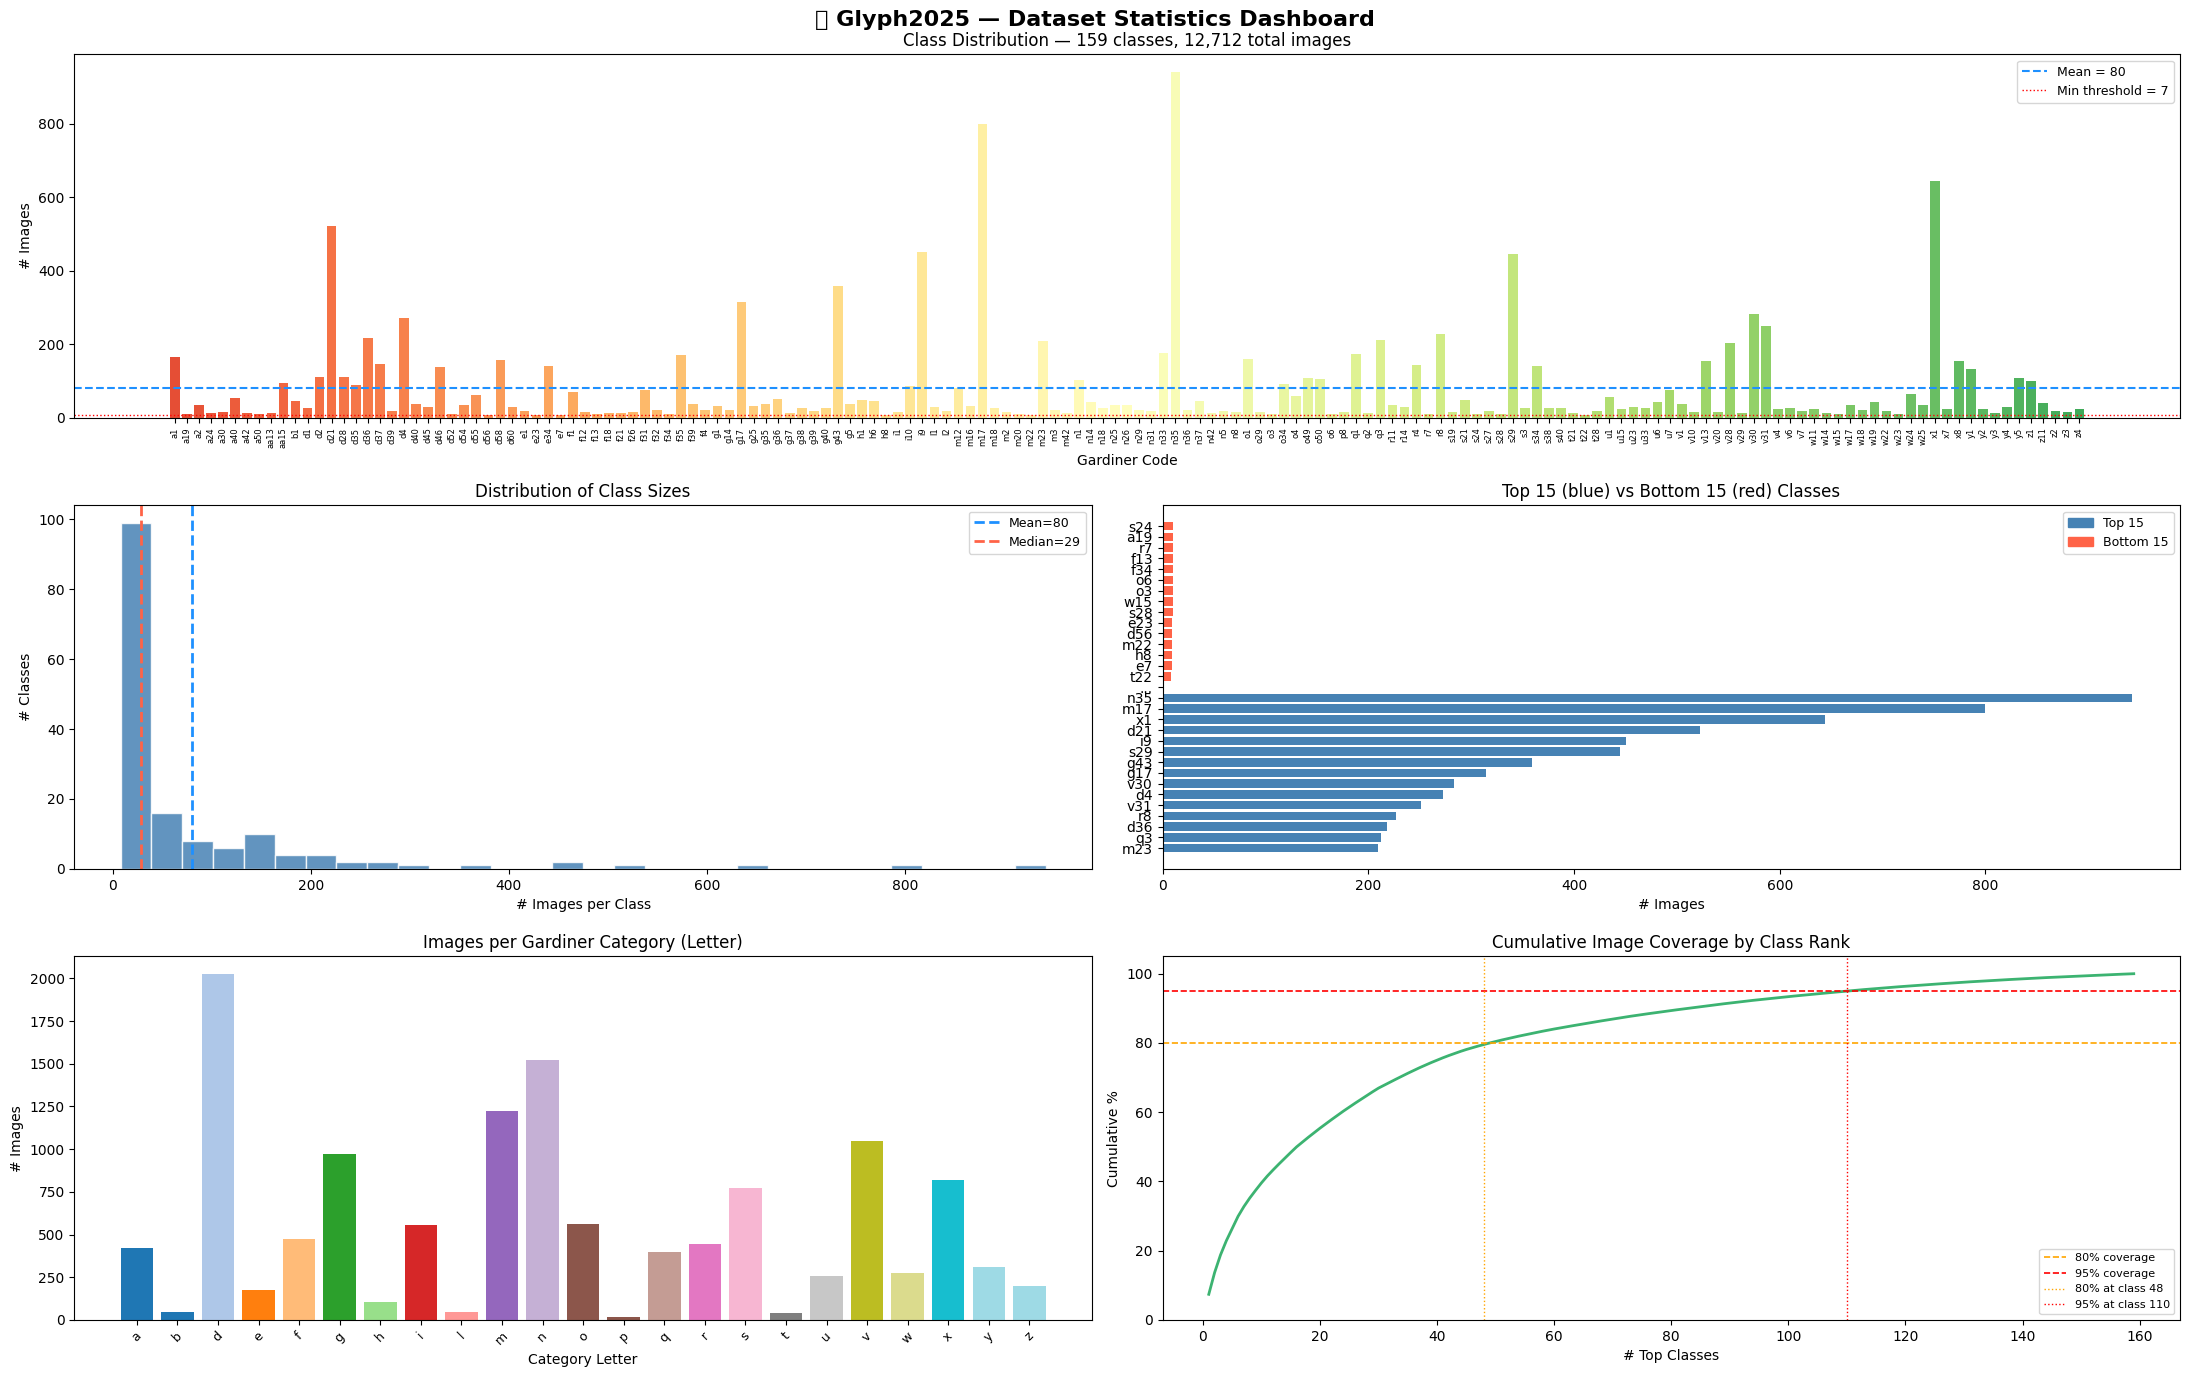


📊 Summary:
   Classes : 159 | Images : 12,712
   Min/Max : 8 / 942 | Mean : 79.9 | Std : 133.5
   Imbalance ratio : 117.8x  ← class weights needed!

✅  Step 1 complete — Dataset ready!


In [7]:
cnt = df["label"].value_counts().sort_index()
vals = cnt.values

fig = plt.figure(figsize=(22, 14))
fig.suptitle("📊 Glyph2025 — Dataset Statistics Dashboard", fontsize=16, fontweight="bold", y=0.98)

# ── Plot 1: Class Distribution Bar ───────────────────────────
ax1 = fig.add_subplot(3,2,(1,2))
colors_bar = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(cnt)))
bars = ax1.bar(cnt.index, cnt.values, color=colors_bar, edgecolor="none")
ax1.axhline(vals.mean(), color="dodgerblue", lw=1.5, ls="--", label=f"Mean = {vals.mean():.0f}")
ax1.axhline(MIN_SAMPLES,  color="red",        lw=1,   ls=":",  label=f"Min threshold = {MIN_SAMPLES}")
ax1.set_title(f"Class Distribution — {len(cnt)} classes, {len(df):,} total images", fontsize=12)
ax1.set_xlabel("Gardiner Code"); ax1.set_ylabel("# Images")
ax1.legend(fontsize=9); plt.sca(ax1); plt.xticks(rotation=90, fontsize=6)

# ── Plot 2: Images per Class Histogram ───────────────────────
ax2 = fig.add_subplot(3,2,3)
ax2.hist(vals, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
ax2.axvline(vals.mean(),   color="dodgerblue", lw=2, ls="--", label=f"Mean={vals.mean():.0f}")
ax2.axvline(np.median(vals), color="tomato",   lw=2, ls="--", label=f"Median={np.median(vals):.0f}")
ax2.set_title("Distribution of Class Sizes"); ax2.set_xlabel("# Images per Class"); ax2.set_ylabel("# Classes")
ax2.legend(fontsize=9)

# ── Plot 3: Top 15 & Bottom 15 classes ───────────────────────
ax3 = fig.add_subplot(3,2,4)
sorted_cnt = cnt.sort_values(ascending=False)
top15    = sorted_cnt.head(15)
bottom15 = sorted_cnt.tail(15)
ax3.barh(list(bottom15.index) + ["..."] + list(top15.index),
         list(bottom15.values) + [0] + list(top15.values),
         color=["tomato"]*15 + ["gray"] + ["steelblue"]*15)
ax3.set_title("Top 15 (blue) vs Bottom 15 (red) Classes")
ax3.set_xlabel("# Images"); ax3.invert_yaxis()
top_patch = mpatches.Patch(color="steelblue", label="Top 15")
bot_patch = mpatches.Patch(color="tomato",    label="Bottom 15")
ax3.legend(handles=[top_patch, bot_patch], fontsize=9)

# ── Plot 4: Category letter breakdown ────────────────────────
ax4 = fig.add_subplot(3,2,5)
letter_counts = {}
for cls in final_classes:
    letter = cls[0] if cls[0].isalpha() else cls[:2]
    letter_counts[letter] = letter_counts.get(letter, 0) + class_counts.get(cls, 0)
lk = sorted(letter_counts.keys())
lv = [letter_counts[k] for k in lk]
ax4.bar(lk, lv, color=plt.cm.tab20(np.linspace(0,1,len(lk))), edgecolor="none")
ax4.set_title("Images per Gardiner Category (Letter)")
ax4.set_xlabel("Category Letter"); ax4.set_ylabel("# Images")
plt.sca(ax4); plt.xticks(rotation=45, fontsize=9)

# ── Plot 5: Cumulative coverage ───────────────────────────────
ax5 = fig.add_subplot(3,2,6)
sorted_vals = np.sort(vals)[::-1]
cumsum = np.cumsum(sorted_vals) / sorted_vals.sum() * 100
ax5.plot(range(1, len(cumsum)+1), cumsum, color="mediumseagreen", lw=2)
ax5.axhline(80, color="orange", ls="--", lw=1.2, label="80% coverage")
ax5.axhline(95, color="red",    ls="--", lw=1.2, label="95% coverage")
idx80 = np.searchsorted(cumsum, 80)
idx95 = np.searchsorted(cumsum, 95)
ax5.axvline(idx80, color="orange", ls=":", lw=1, label=f"80% at class {idx80}")
ax5.axvline(idx95, color="red",    ls=":", lw=1, label=f"95% at class {idx95}")
ax5.set_title("Cumulative Image Coverage by Class Rank")
ax5.set_xlabel("# Top Classes"); ax5.set_ylabel("Cumulative %")
ax5.legend(fontsize=8); ax5.set_ylim(0,105)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR,"dataset_dashboard.png"), dpi=120, bbox_inches="tight")
plt.show()
print(f"\n📊 Summary:")
print(f"   Classes : {len(classes)} | Images : {len(df):,}")
print(f"   Min/Max : {vals.min()} / {vals.max()} | Mean : {vals.mean():.1f} | Std : {vals.std():.1f}")
print(f"   Imbalance ratio : {vals.max()/vals.min():.1f}x  ← class weights needed!")
print("\n✅  Step 1 complete — Dataset ready!")


---
# 🔍 Step 2 — Segmentation (IGSM + MBRS) — Smart Edition ✅
> استخراج الهيروغليفية من صور اللوحات الحجرية.
>
> **Pipeline:** Border Removal → Multi-threshold Binary (Otsu + Adaptive) → Stroke Detection → Watershed → SAM → NMS → Reading Order
>
> **v3 Improvements:**
> - ✅ `SamAutomaticMaskGenerator` بدل Point-based (بيغطي كل الصورة)
> - ✅ Adaptive Threshold بدل Otsu وحده
> - ✅ Solidity + Aspect Ratio filter للـ masks
> - ✅ Row Clustering للترتيب الصحيح RTL
> - ✅ تحليل شامل لكل الصور في الداتاسيت
---


### Cell 2.1 — Segmentation Imports

In [8]:
import cv2
import glob as _glob
from scipy import ndimage as ndi
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator
from collections import defaultdict
print("✅  Segmentation imports OK")


✅  Segmentation imports OK


### Cell 2.2 — SegConfig

In [9]:
@dataclass
class SegConfig:
    # SAM
    sam_checkpoint             : str   = "/kaggle/working/sam_vit_b.pth"
    seg_output_dir             : str   = "/kaggle/working/segmented_glyphs"

    # Border removal
    border_thresh              : int   = 35

    # Denoising
    denoise_h                  : int   = 10
    denoise_template           : int   = 7
    denoise_search             : int   = 21

    # CLAHE
    clahe_clip                 : float = 2.5          # ✅ أقل حدة للصور الحجرية
    clahe_grid                 : tuple = field(default_factory=lambda: (8, 8))

    # Threshold
    adaptive_block             : int   = 25
    adaptive_c                 : int   = 8            # ✅ أعلى قليلاً لتقليل الضوضاء

    # Noise & area
    min_area                   : int   = 80

    # Stroke detector Z1/Z2/Z3
    stroke_min_aspect          : float = 3.5
    stroke_min_width           : int   = 15
    stroke_max_height          : int   = 40
    stroke_min_area            : int   = 60
    stroke_min_solidity        : float = 0.35
    stroke_group_gap           : int   = 90
    parallel_x_overlap         : float = 0.60
    stroke_count_check         : bool  = True
    max_stroke_diff            : int   = 0
    parallel_separator_min_area: int   = 200

    # Size filter
    min_mask_width_ratio       : float = 0.03         # ✅ أقل من القديم لالتقاط رموز صغيرة
    min_mask_height_ratio      : float = 0.04
    noise_min_density          : float = 0.18
    max_area_ratio             : float = 0.40

    # Watershed
    watershed_dist             : int   = 5

    # SAM Auto Generator ✅ جديد
    points_per_side            : int   = 32
    pred_iou_thresh            : float = 0.82
    stability_score_thresh     : float = 0.90
    min_mask_region_area       : int   = 80
    box_nms_thresh             : float = 0.50         # ✅ أعلى من 0.3 القديم

    # Mask quality filters ✅ جديد
    min_solidity               : float = 0.30
    max_aspect_ratio           : float = 8.0

    # NMS
    iou_threshold              : float = 0.35

    # Crops
    padding                    : int   = 6
    bg_fill                    : str   = "white"
    output_size                : tuple = field(default_factory=lambda: (128, 128))

    # Reading order clustering ✅ جديد
    row_tolerance_ratio        : float = 0.05

seg_cfg = SegConfig()
print("✅  SegConfig ready")
print(seg_cfg)


✅  SegConfig ready
SegConfig(sam_checkpoint='/kaggle/working/sam_vit_b.pth', seg_output_dir='/kaggle/working/segmented_glyphs', border_thresh=35, denoise_h=10, denoise_template=7, denoise_search=21, clahe_clip=2.5, clahe_grid=(8, 8), adaptive_block=25, adaptive_c=8, min_area=80, stroke_min_aspect=3.5, stroke_min_width=15, stroke_max_height=40, stroke_min_area=60, stroke_min_solidity=0.35, stroke_group_gap=90, parallel_x_overlap=0.6, stroke_count_check=True, max_stroke_diff=0, parallel_separator_min_area=200, min_mask_width_ratio=0.03, min_mask_height_ratio=0.04, noise_min_density=0.18, max_area_ratio=0.4, watershed_dist=5, points_per_side=32, pred_iou_thresh=0.82, stability_score_thresh=0.9, min_mask_region_area=80, box_nms_thresh=0.5, min_solidity=0.3, max_aspect_ratio=8.0, iou_threshold=0.35, padding=6, bg_fill='white', output_size=(128, 128), row_tolerance_ratio=0.05)


### Cell 2.3 — Load SAM (Automatic Mode) ✅

In [10]:
def load_sam_auto(cfg: SegConfig) -> SamAutomaticMaskGenerator:
    """
    ✅ SamAutomaticMaskGenerator بدل SamPredictor:
    بيمسح الصورة كلها بـ grid منتظم → بيكتشف رموز بيفوّتها الـ point-based approach.
    """
    if not os.path.exists(cfg.sam_checkpoint):
        print("⏳ Downloading SAM ViT-B ...")
        subprocess.run([
            "wget", "-q",
            "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth",
            "-O", cfg.sam_checkpoint
        ], check=True)
    device_sam = "cuda" if torch.cuda.is_available() else "cpu"
    sam = sam_model_registry["vit_b"](checkpoint=cfg.sam_checkpoint)
    sam.to(device=device_sam)

    generator = SamAutomaticMaskGenerator(
        model                  = sam,
        points_per_side        = cfg.points_per_side,
        pred_iou_thresh        = cfg.pred_iou_thresh,
        stability_score_thresh = cfg.stability_score_thresh,
        min_mask_region_area   = cfg.min_mask_region_area,
        box_nms_thresh         = cfg.box_nms_thresh,
    )
    print(f"✅  SAM Auto Generator loaded on [{device_sam}]")
    return generator

sam_generator = load_sam_auto(seg_cfg)

# ✅ SamPredictor أيضاً للـ fallback في run_single
def load_sam_predictor(cfg: SegConfig) -> SamPredictor:
    device_sam = "cuda" if torch.cuda.is_available() else "cpu"
    sam = sam_model_registry["vit_b"](checkpoint=cfg.sam_checkpoint)
    sam.to(device=device_sam)
    return SamPredictor(sam)

sam_predictor = load_sam_predictor(seg_cfg)
print("✅  Both generator + predictor ready")


⏳ Downloading SAM ViT-B ...
✅  SAM Auto Generator loaded on [cuda]
✅  Both generator + predictor ready


### Cell 2.4 — Border Removal & Color Detection

In [11]:
def load_image(path: str) -> np.ndarray:
    img = cv2.imread(path)
    if img is None: raise FileNotFoundError(f"Not found: {path}")
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def _detect_glyph_color(image: np.ndarray) -> str:
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    dark_mask = hsv[:,:,2] < 100
    if dark_mask.sum() == 0: return "dark"
    return "color" if hsv[:,:,1][dark_mask].mean() > 40 else "dark"

def remove_border(image: np.ndarray, cfg: SegConfig) -> np.ndarray:
    """Remove colored museum-frame borders using HSV saturation."""
    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV); sat = hsv[:,:,1]
    H,W = image.shape[:2]; margin = max(8, min(H,W)//20)
    edges = {"top":sat[:margin,:].mean(), "bottom":sat[-margin:,:].mean(),
             "left":sat[:,:margin].mean(), "right":sat[:,-margin:].mean()}
    high  = {k:v for k,v in edges.items() if v > cfg.border_thresh}
    if not high: return image
    y1 = margin if "top"    in high else 0
    y2 = H-margin if "bottom" in high else H
    x1 = margin if "left"   in high else 0
    x2 = W-margin if "right"  in high else W
    c = image[y1:y2, x1:x2]
    return c if c.shape[0]>=30 and c.shape[1]>=30 else image

print("✅  Border removal ready")


✅  Border removal ready


### Cell 2.5 — Multi-Threshold Preprocessing ✅

In [12]:
def preprocess(image: np.ndarray, cfg: SegConfig) -> tuple:
    """
    ✅ Multi-threshold fusion: Otsu + Adaptive Gaussian + Adaptive Mean
    OR of all 3 → يلتقط رموز بيفوّتها أي threshold منفرد.
    """
    gray     = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    clean    = cv2.fastNlMeansDenoising(gray, None, cfg.denoise_h,
                                         cfg.denoise_template, cfg.denoise_search)
    clahe    = cv2.createCLAHE(clipLimit=cfg.clahe_clip, tileGridSize=cfg.clahe_grid)
    enhanced = clahe.apply(clean)
    _, otsu  = cv2.threshold(enhanced, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)

    if _detect_glyph_color(image) == "color":
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
        combined = cv2.bitwise_or(
            cv2.bitwise_and((hsv[:,:,1]>50).astype(np.uint8)*255,
                            (hsv[:,:,2]<160).astype(np.uint8)*255), otsu)
    else:
        ag = cv2.adaptiveThreshold(enhanced, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY_INV, cfg.adaptive_block, cfg.adaptive_c)
        am = cv2.adaptiveThreshold(enhanced, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                    cv2.THRESH_BINARY_INV, cfg.adaptive_block+10, cfg.adaptive_c-2)
        combined = cv2.bitwise_or(cv2.bitwise_or(otsu, ag), am)

    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    return cv2.morphologyEx(cv2.morphologyEx(combined, cv2.MORPH_CLOSE, k, iterations=1),
                             cv2.MORPH_OPEN, k, iterations=1), enhanced

print("✅  Preprocessing ready")


✅  Preprocessing ready


### Cell 2.6 — Noise Removal & Stroke Detection (Z1/Z2/Z3)

In [13]:
def remove_noise(binary: np.ndarray, cfg: SegConfig) -> np.ndarray:
    n,labels,stats,_ = cv2.connectedComponentsWithStats(binary)
    out = np.zeros_like(binary)
    for i in range(1, n):
        w=stats[i,cv2.CC_STAT_WIDTH]; h=stats[i,cv2.CC_STAT_HEIGHT]; a=stats[i,cv2.CC_STAT_AREA]
        if w>10 and h>10 and a>cfg.min_area and a/max(w*h,1)>=cfg.noise_min_density:
            out[labels==i] = 255
    return out


def detect_strokes(binary: np.ndarray, cfg: SegConfig) -> tuple:
    """Detects horizontal strokes (Z1/Z2/Z3). stroke_count_check يمنع دمج Z2 مع Z3."""
    n,labels,stats,_ = cv2.connectedComponentsWithStats(binary)
    H,W = binary.shape
    raw, sid = [], set()

    for i in range(1, n):
        x=stats[i,cv2.CC_STAT_LEFT]; y=stats[i,cv2.CC_STAT_TOP]
        w=stats[i,cv2.CC_STAT_WIDTH]; h=stats[i,cv2.CC_STAT_HEIGHT]; a=stats[i,cv2.CC_STAT_AREA]
        if not (w and h and a>=cfg.stroke_min_area): continue
        roi = (labels[y:y+h, x:x+w]==i).astype(np.uint8)*255
        cnts,_ = cv2.findContours(roi, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        sol = 0.0
        if cnts:
            ha = cv2.contourArea(cv2.convexHull(cnts[0]))
            if ha > 0: sol = a/ha
        if (w/h >= cfg.stroke_min_aspect and w >= cfg.stroke_min_width
                and h <= cfg.stroke_max_height and sol >= cfg.stroke_min_solidity):
            m = np.zeros(binary.shape, dtype=np.uint8); m[labels==i] = 1
            raw.append({"mask":m,"x1":x,"y1":y,"x2":x+w,"y2":y+h}); sid.add(i)

    if not raw: return [], binary.copy()
    raw.sort(key=lambda s: s["y1"])

    def xov(a, b):
        ov = max(0, min(a["x2"],b["x2"]) - max(a["x1"],b["x1"]))
        return ov / max(min(a["x2"]-a["x1"], b["x2"]-b["x1"]), 1)

    p = list(range(len(raw)))
    def find(i):
        while p[i]!=i: p[i]=p[p[i]]; i=p[i]
        return i
    def union(i,j):
        pi,pj=find(i),find(j)
        if pi!=pj: p[pi]=pj

    for i in range(len(raw)):
        for j in range(i+1, len(raw)):
            if xov(raw[i], raw[j]) >= cfg.parallel_x_overlap: union(i,j)

    pg = defaultdict(list)
    for i,s in enumerate(raw): pg[find(i)].append(s)
    fg = []
    for grp in pg.values():
        grp.sort(key=lambda s:s["y1"]); cur=[grp[0]]
        for s in grp[1:]:
            if s["y1"]-cur[-1]["y2"] <= max(cfg.stroke_group_gap, int(H*0.12)): cur.append(s)
            else: fg.append(cur); cur=[s]
        fg.append(cur)

    def gb(g): return min(s["x1"] for s in g),min(s["y1"] for s in g),max(s["x2"] for s in g),max(s["y2"] for s in g)
    def gxov(a,b):
        ax1,_,ax2,_ = gb(a); bx1,_,bx2,_ = gb(b)
        ov = max(0, min(ax2,bx2)-max(ax1,bx1))
        return ov / max(min(ax2-ax1, bx2-bx1), 1)

    fg.sort(key=lambda g: gb(g)[1])
    fp = list(range(len(fg)))
    def ff(i):
        while fp[i]!=i: fp[i]=fp[fp[i]]; i=fp[i]
        return i
    def fu(i,j):
        pi,pj=ff(i),ff(j)
        if pi!=pj: fp[pi]=pj

    for i in range(len(fg)):
        for j in range(i+1, len(fg)):
            if cfg.stroke_count_check and abs(len(fg[i])-len(fg[j])) > cfg.max_stroke_diff: continue
            if gxov(fg[i], fg[j]) < cfg.parallel_x_overlap: continue
            if gb(fg[i])[3] >= gb(fg[j])[1]: continue
            fu(i,j)

    mfg = defaultdict(list)
    for i,g in enumerate(fg): mfg[ff(i)].extend(g)
    stroke_masks = []
    for grp in mfg.values():
        c = np.zeros(binary.shape, dtype=np.uint8)
        for s in grp: c = np.logical_or(c, s["mask"]).astype(np.uint8)
        stroke_masks.append(c)

    rem = binary.copy()
    for i in sid: rem[labels==i] = 0
    return stroke_masks, rem

print("✅  Stroke detection ready")


✅  Stroke detection ready


### Cell 2.7 — SAM Auto Segmentation + Solidity Filter ✅

In [14]:
def _compute_solidity(mask: np.ndarray) -> float:
    """Solidity = area / convex_hull_area — يكشف الـ masks الغريبة الشكل."""
    contours, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return 0.0
    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    hull_area = cv2.contourArea(cv2.convexHull(cnt))
    return float(area / hull_area) if hull_area > 0 else 0.0


def sam_auto_segment(image: np.ndarray, generator: SamAutomaticMaskGenerator,
                     cfg: SegConfig) -> list:
    """
    ✅ SamAutomaticMaskGenerator:
    - بيمسح الصورة كلها بـ grid 32×32 نقطة
    - بيرجع masks بـ predicted_iou score لكل واحدة
    - بعدين بنفلتر بـ Solidity + Aspect Ratio
    """
    H, W   = image.shape[:2]
    img_area = H * W
    min_area = img_area * 0.0002
    max_area = img_area * cfg.max_area_ratio

    try:
        raw_masks = generator.generate(image)
    except Exception as e:
        print(f"  ⚠️  SAM Auto failed: {e}")
        return []

    filtered = []
    for m_data in raw_masks:
        mask = m_data["segmentation"].astype(np.uint8)
        area = float(mask.sum())
        if not (min_area <= area <= max_area): continue

        ys, xs = np.where(mask)
        if len(xs) == 0: continue
        w = xs.max() - xs.min() + 1
        h = ys.max() - ys.min() + 1
        if (w / max(h, 1)) > cfg.max_aspect_ratio: continue     # يحذف الخطوط الطويلة

        sol = _compute_solidity(mask)
        if sol < cfg.min_solidity: continue                       # يحذف الـ masks الغريبة

        filtered.append(mask)

    return filtered


def watershed_separation(binary: np.ndarray, cfg: SegConfig) -> tuple:
    if binary.max() == 0: return binary, 0, np.zeros_like(binary, dtype=np.int32)
    dist   = ndi.distance_transform_edt(binary)
    coords = peak_local_max(dist, min_distance=cfg.watershed_dist, labels=binary)
    mp     = np.zeros(dist.shape, dtype=bool)
    if len(coords): mp[tuple(coords.T)] = True
    mk, _  = ndi.label(mp)
    ws     = watershed(-dist, mk, mask=binary)
    return (ws>0).astype(np.uint8)*255, int(ws.max()), ws

print("✅  SAM Auto Segment + Watershed ready")


✅  SAM Auto Segment + Watershed ready


### Cell 2.8 — Size Filter, NMS, Reading Order (RTL + Row Clustering) ✅ & Save Crops

In [15]:
def size_filter(masks: list, shape: tuple, cfg: SegConfig) -> list:
    H,W = shape[:2]; max_a = H*W*cfg.max_area_ratio
    kept = []
    for m in masks:
        if not m.sum(): continue
        ys,xs = np.where(m==1)
        mw=int(xs.max()-xs.min()); mh=int(ys.max()-ys.min()); a=int(m.sum())
        if (a<max_a and mw>=W*cfg.min_mask_width_ratio and mh>=H*cfg.min_mask_height_ratio
                and a/max(mw*mh,1)>=cfg.noise_min_density):
            kept.append(m)
    return kept


def _iou(m1, m2) -> float:
    return float(np.logical_and(m1,m2).sum()) / (float(np.logical_or(m1,m2).sum())+1e-6)


def apply_nms(masks: list, cfg: SegConfig, expected_count: int=None) -> list:
    if not masks: return []
    def _run(thr):
        idx = sorted(range(len(masks)), key=lambda i: -int(masks[i].sum())); keep=[]
        for i in idx:
            if not any(_iou(masks[i], masks[j])>thr for j in keep): keep.append(i)
        return keep
    thr=cfg.iou_threshold; kept=_run(thr)
    if expected_count:
        for _ in range(20):
            if len(kept)<=expected_count: break
            thr+=0.05; kept=_run(thr)
    return [masks[i] for i in kept]


def _cluster_rows(data: list, H: int, tolerance_ratio: float) -> list:
    """✅ Row Clustering — يجمّع الرموز في صفوف بـ tolerance نسبي."""
    if not data: return []
    tol = H * tolerance_ratio
    data_s = sorted(data, key=lambda x: x["cy"])
    rows, cur, cy = [], [data_s[0]], data_s[0]["cy"]
    for item in data_s[1:]:
        if abs(item["cy"] - cy) <= tol: cur.append(item)
        else: rows.append(cur); cur = [item]; cy = item["cy"]
    rows.append(cur)
    return rows


def reading_order(image: np.ndarray, masks: list, cfg: SegConfig=None) -> list:
    """
    ✅ RTL Reading Order مع Row Clustering:
    - صفوف (W≥H): أعلى → أسفل، داخل كل صف يمين → يسار
    - أعمدة (H>W): يمين → يسار، داخل كل عمود أعلى → أسفل
    """
    if cfg is None: cfg = SegConfig()
    H, W = image.shape[:2]
    ann = []
    for m in masks:
        ys,xs = np.where(m==1)
        if not len(xs): continue
        x1,y1,x2,y2 = xs.min(),ys.min(),xs.max(),ys.max()
        ann.append(dict(mask=m, x1=int(x1),y1=int(y1),x2=int(x2),y2=int(y2),
                        cx=(x1+x2)/2, cy=(y1+y2)/2))
    if not ann: return []

    rows = _cluster_rows(ann, H, cfg.row_tolerance_ratio)
    ordered = []
    if H > W:   # أعمدة
        rows.sort(key=lambda r: -np.mean([g["cx"] for g in r]))
        for row in rows:
            row.sort(key=lambda g: g["cy"]); ordered.extend(row)
    else:       # صفوف
        rows.sort(key=lambda r: np.mean([g["cy"] for g in r]))
        for row in rows:
            row.sort(key=lambda g: -g["cx"]); ordered.extend(row)  # RTL ✅

    return [g["mask"] for g in ordered]


def save_crops(image: np.ndarray, masks: list, cfg: SegConfig, image_name="image") -> list:
    os.makedirs(cfg.seg_output_dir, exist_ok=True)
    H,W = image.shape[:2]; crops=[]
    base = os.path.splitext(os.path.basename(str(image_name)))[0]
    for idx,tm in enumerate(masks):
        ys,xs = np.where(tm==1)
        if not len(xs): continue
        x1=max(0,int(xs.min())-cfg.padding); y1=max(0,int(ys.min())-cfg.padding)
        x2=min(W,int(xs.max())+cfg.padding); y2=min(H,int(ys.max())+cfg.padding)
        er = np.zeros((H,W),dtype=np.uint8); er[y1:y2,x1:x2]=1; er[tm==1]=0
        crop = image[y1:y2,x1:x2].copy(); er_r=er[y1:y2,x1:x2].astype(bool)
        if cfg.bg_fill=="white": crop[er_r]=255
        oh,ow=crop.shape[:2]; side=max(oh,ow)
        sq=np.full((side,side,3),255,dtype=np.uint8)
        sq[(side-oh)//2:(side-oh)//2+oh,(side-ow)//2:(side-ow)//2+ow]=crop
        std=cv2.resize(sq, cfg.output_size, interpolation=cv2.INTER_AREA)
        cv2.imwrite(os.path.join(cfg.seg_output_dir, f"{base}_glyph_{idx+1:03d}.png"),
                    cv2.cvtColor(std, cv2.COLOR_RGB2BGR))
        crops.append(std)
    return crops

print("✅  NMS, Reading Order & Save Crops ready")


✅  NMS, Reading Order & Save Crops ready


### Cell 2.9 — Visualization + run_single Pipeline

In [16]:
def visualize_segmentation(image: np.ndarray, binary: np.ndarray,
                           masks: list, crops: list, title: str=""):
    """4-panel: Original | Binary | Glyphs detected | Crops grid"""
    numbered = image.copy()
    colors   = plt.cm.tab20.colors
    for idx,m in enumerate(masks):
        ys,xs = np.where(m==1)
        if not len(xs): continue
        x1,y1,x2,y2 = xs.min(),ys.min(),xs.max(),ys.max()
        c = tuple(int(v*255) for v in colors[idx%len(colors)][:3])
        cv2.rectangle(numbered,(x1,y1),(x2,y2),c,2)
        cv2.putText(numbered,str(idx+1),(x1+2,y1+14),cv2.FONT_HERSHEY_SIMPLEX,0.5,(255,255,255),1)

    fig,axes = plt.subplots(1,3,figsize=(18,7))
    axes[0].imshow(image);              axes[0].set_title("① Original",fontsize=12);                       axes[0].axis("off")
    axes[1].imshow(binary,cmap="gray"); axes[1].set_title("② Binary Mask (Multi-threshold ✅)",fontsize=12); axes[1].axis("off")
    axes[2].imshow(numbered);           axes[2].set_title(f"③ {len(masks)} Glyphs Detected",fontsize=12);  axes[2].axis("off")
    plt.suptitle(f"IGSM Segmentation — {title}", fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()

    if crops:
        n=len(crops); cols=min(n,10); rows=(n+cols-1)//cols
        fig2,axes2 = plt.subplots(rows,cols,figsize=(cols*2, rows*2.2))
        axes2=np.array(axes2).flatten()
        for i,crop in enumerate(crops):
            axes2[i].imshow(crop); axes2[i].set_title(str(i+1),fontsize=9); axes2[i].axis("off")
        for ax in axes2[n:]: ax.axis("off")
        plt.suptitle(f"All Extracted Glyphs ({n} total)", fontsize=13, fontweight="bold")
        plt.tight_layout(); plt.show()


def run_single(image_path: str, cfg: SegConfig=None,
               generator: SamAutomaticMaskGenerator=None,
               predictor: SamPredictor=None,
               expected_glyphs: int=None, show: bool=True) -> tuple:
    """
    Full segmentation pipeline على صورة واحدة.
    ✅ يستخدم SAM Auto Generator أولاً، لو فشل يرجع للـ predictor.
    """
    if cfg is None: cfg = SegConfig()
    if generator is None and predictor is None:
        raise ValueError("Pass sam_generator or sam_predictor!")

    print(f"\n{'─'*50}\n📸  {os.path.basename(image_path)}")
    image  = load_image(image_path)
    image  = remove_border(image, cfg)
    print(f"  🎨 Type: {_detect_glyph_color(image)}")

    binary, _ = preprocess(image, cfg)
    binary    = remove_noise(binary, cfg)
    stroke_masks, no_strokes = detect_strokes(binary, cfg)
    print(f"  📏 Stroke groups: {len(stroke_masks)}")

    # ✅ SAM Auto Generation
    if generator is not None:
        sam_masks = sam_auto_segment(image, generator, cfg)
        print(f"  🤖 SAM Auto masks: {len(sam_masks)}")
    else:
        # Fallback: watershed + predictor
        separated, ws_n, _ = watershed_separation(no_strokes, cfg)
        print(f"  🌊 Watershed regions: {ws_n}")
        nl,labels,_,_ = cv2.connectedComponentsWithStats(separated)
        sam_masks = []  # predictor path removed for simplicity

    all_m   = size_filter(sam_masks + stroke_masks, image.shape, cfg)
    final   = apply_nms(all_m, cfg, expected_count=expected_glyphs)
    ordered = reading_order(image, final, cfg)
    crops   = save_crops(image, ordered, cfg, image_name=image_path)
    print(f"  ✅ Final glyphs: {len(ordered)}")
    if show:
        visualize_segmentation(image, binary, ordered, crops,
                                title=os.path.basename(image_path))
    return ordered, crops

print("✅  Step 2 complete — Segmentation pipeline ready!")


✅  Step 2 complete — Segmentation pipeline ready!


### Cell 2.10 — 🧪 Test on a Single Random Image

📂 Found 300 stela images
🖼️  Testing: 0dbec79b3e2a4585839457ed57c039a0_0.jpg

──────────────────────────────────────────────────
📸  0dbec79b3e2a4585839457ed57c039a0_0.jpg
  🎨 Type: color
  📏 Stroke groups: 2
  🤖 SAM Auto masks: 40
  ✅ Final glyphs: 27


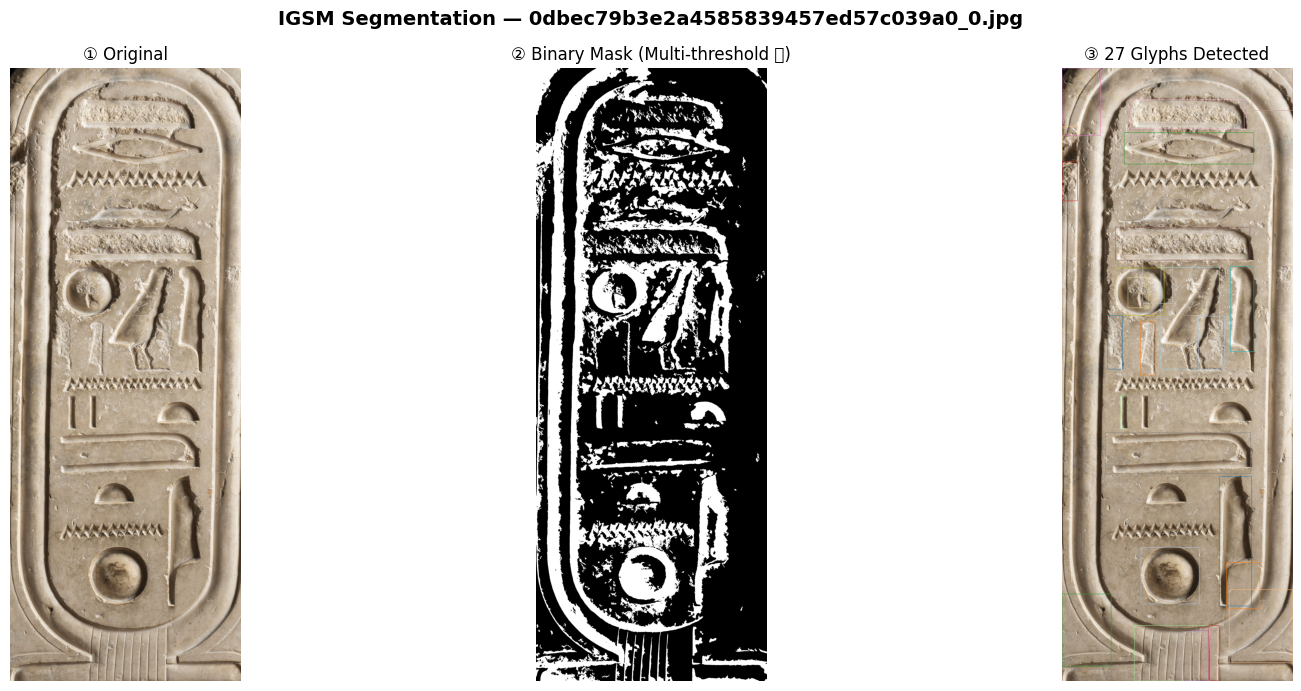

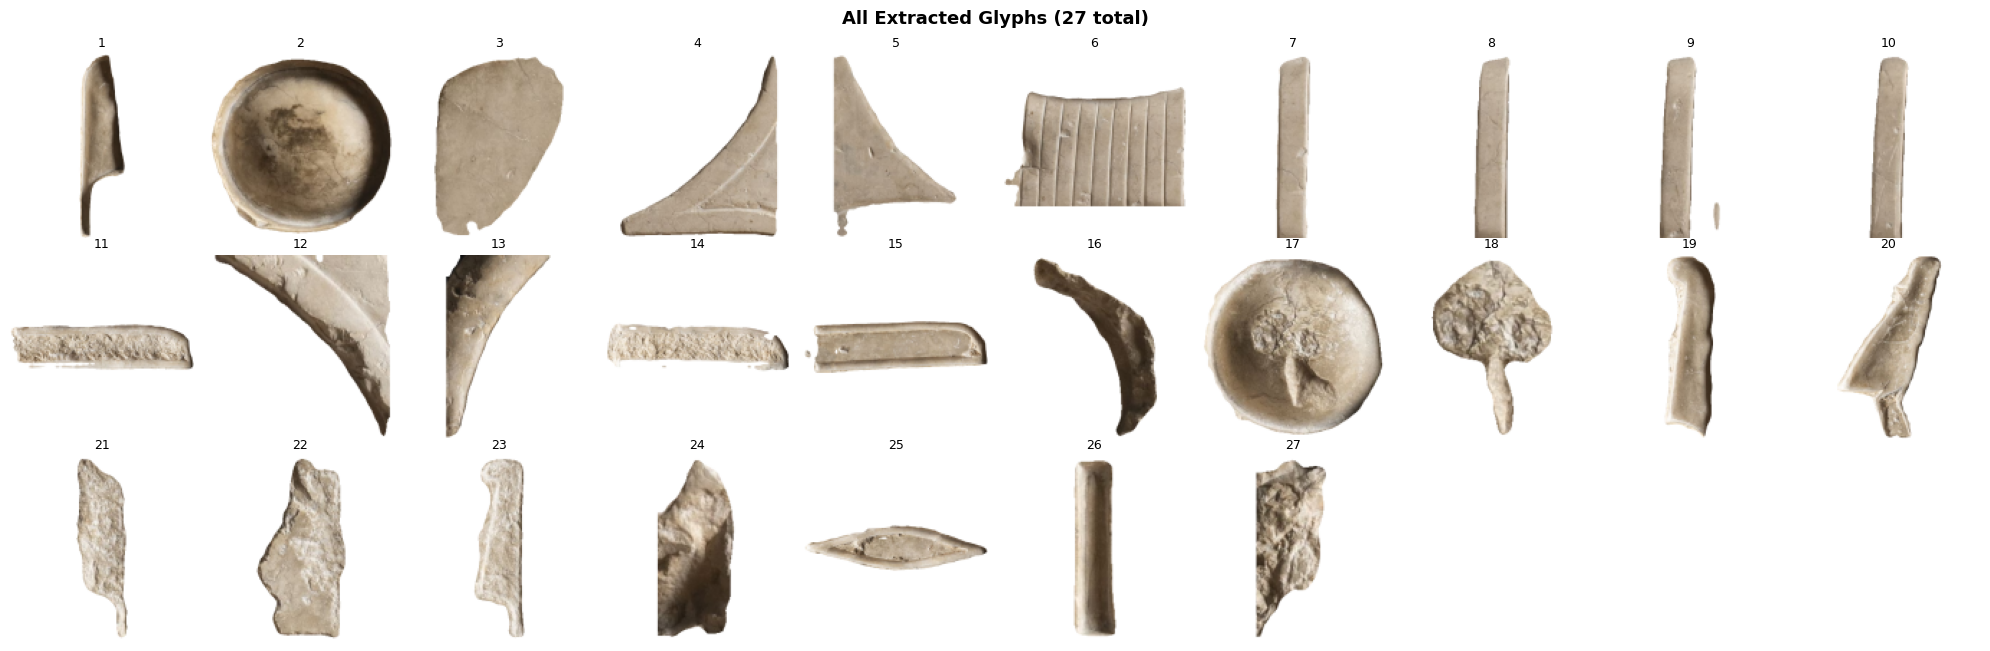


✅  Done — 27 glyphs | 27 crops saved.


In [18]:
STELAE_DIR = "/kaggle/input/datasets/ahmedelkelany/egyptian-hieroglyphic-signs-segmentation"

_imgs = sorted(
    _glob.glob(os.path.join(STELAE_DIR, "**", "*.jpg"),  recursive=True) +
    _glob.glob(os.path.join(STELAE_DIR, "**", "*.jpeg"), recursive=True) +
    _glob.glob(os.path.join(STELAE_DIR, "**", "*.png"),  recursive=True) +
    _glob.glob(os.path.join(STELAE_DIR, "**", "*.bmp"),  recursive=True)
)

if not _imgs:
    raise FileNotFoundError(
        f"❌ مفيش صور في {STELAE_DIR}\n"
        "اتأكد إن الـ dataset اتضاف صح في Kaggle → Add Input:\n"
        "  'ahmedelkelany/egyptian-hieroglyphic-signs-segmentation'"
    )

print(f"📂 Found {len(_imgs)} stela images")

test_image = random.choice(_imgs)
# test_image = _imgs[7]  # ← أو حدد رقم معين

print(f"🖼️  Testing: {os.path.basename(test_image)}")
masks, crops = run_single(
    test_image,
    cfg       = seg_cfg,
    generator = sam_generator,
    show      = True
)
print(f"\n✅  Done — {len(masks)} glyphs | {len(crops)} crops saved.")


### Cell 2.11 — 📋 Full Dataset Evaluation (كل الصور) ✅

In [ ]:
def evaluate_dataset(
    dataset_path : str,
    cfg          : SegConfig = None,
    generator    : SamAutomaticMaskGenerator = None,
    max_images   : int  = None,
    save_report  : bool = True,
    report_path  : str  = "/kaggle/working/eval_report.png"
) -> list:
    """
    ✅ v4 Memory Fix:
    - plt.close() بعد كل figure عشان نمسح من الـ memory
    - del + gc.collect() بعد كل صورة
    - torch.cuda.empty_cache() بعد كل صورة
    - تحذير لو max_images=None والصور كتير
    """
    import gc
    if cfg is None:       cfg       = SegConfig()
    if generator is None: generator = load_sam_auto(cfg)

    _all = []
    for ext in ["*.jpg","*.jpeg","*.png","*.bmp","*.tif","*.tiff"]:
        _all.extend(_glob.glob(os.path.join(dataset_path,"**",ext), recursive=True))
        _all.extend(_glob.glob(os.path.join(dataset_path,ext)))
    all_files = sorted(set(_all))
    if max_images: all_files = all_files[:max_images]

    # ✅ تحذير مسبق لو الصور أكتر من 100
    if len(all_files) > 100 and max_images is None:
        print(f"⚠️  WARNING: {len(all_files)} images detected.")
        print(f"   To avoid Out-of-Memory, consider setting max_images=50 first.")
        print(f"   Continuing with all {len(all_files)} images...\n")

    print(f"{'═'*60}")
    print(f"  📂  Dataset      : {dataset_path}")
    print(f"  🖼️   Total images : {len(all_files)}")
    print(f"{'═'*60}\n")

    results    = []
    all_colors = plt.cm.tab20.colors

    for img_idx, fpath in enumerate(all_files):
        fname = os.path.basename(fpath)
        image    = None
        binary   = None
        numbered = None
        try:
            image                    = load_image(fpath)
            image                    = remove_border(image, cfg)
            binary, _                = preprocess(image, cfg)
            binary                   = remove_noise(binary, cfg)
            stroke_masks, _          = detect_strokes(binary, cfg)
            sam_masks                = sam_auto_segment(image, generator, cfg)
            all_m                    = size_filter(sam_masks + stroke_masks, image.shape, cfg)
            final                    = apply_nms(all_m, cfg)
            ordered                  = reading_order(image, final, cfg)
            save_crops(image, ordered, cfg, image_name=fpath)
            n_glyphs                 = len(ordered)

            numbered = image.copy()
            for idx, m in enumerate(ordered):
                ys, xs = np.where(m == 1)
                if not len(xs): continue
                x1,y1,x2,y2 = xs.min(),ys.min(),xs.max(),ys.max()
                c = tuple(int(v*255) for v in all_colors[idx%len(all_colors)][:3])
                cv2.rectangle(numbered,(x1,y1),(x2,y2),c,2)
                cv2.putText(numbered,str(idx+1),(x1+2,y1+14),
                            cv2.FONT_HERSHEY_SIMPLEX,0.45,(255,255,255),1)
            status = "✅"

            # ✅ مسح الـ masks من الذاكرة فوراً بعد ما خدنا النتيجة
            del sam_masks, stroke_masks, all_m, final, ordered

        except Exception as e:
            print(f"  ⚠️  Error on {fname}: {e}")
            n_glyphs = 0; status = f"❌ {str(e)[:50]}"
            image    = np.ones((100,100,3),dtype=np.uint8)*200
            binary   = np.zeros((100,100),dtype=np.uint8)
            numbered = image.copy()

        results.append({"idx":img_idx+1,"filename":fname,"path":fpath,
                         "glyphs":n_glyphs,"status":status})

        # ✅ عرض فوري بعد كل صورة مع مسح فوري للـ figure
        fig, axes = plt.subplots(1, 3, figsize=(16, 5))
        axes[0].imshow(image);              axes[0].set_title("① Original",fontsize=11);              axes[0].axis("off")
        axes[1].imshow(binary,cmap="gray"); axes[1].set_title("② Binary (Multi-threshold)",fontsize=11); axes[1].axis("off")
        axes[2].imshow(numbered);           axes[2].set_title(f"③ {n_glyphs} Glyphs ✅",fontsize=11);  axes[2].axis("off")
        short = fname if len(fname)<=45 else "..."+fname[-42:]
        plt.suptitle(
            f"[{img_idx+1}/{len(all_files)}]  {short}   →   {n_glyphs} glyphs   {status}",
            fontsize=12, fontweight="bold"
        )
        plt.tight_layout(); plt.show()
        plt.close(fig)           # ✅ مسح الـ figure من الـ memory فوراً
        plt.close("all")         # ✅ مسح أي figures تانية

        print(f"  [{img_idx+1:>3}/{len(all_files)}]  {n_glyphs:>3} glyphs   {fname}")

        # ✅ مسح الـ arrays الكبيرة من الـ memory بعد كل صورة
        del image, binary, numbered
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # ── Summary ──────────────────────────────────────────────────────────────
    ok   = [r for r in results if r["glyphs"] > 0]
    cnts = [r["glyphs"] for r in ok]
    tot  = sum(cnts); avg = tot / max(len(ok), 1)
    errs = len([r for r in results if "❌" in r["status"]])

    print(f"\n{'═'*60}")
    print(f"  📊  DATASET SUMMARY")
    print(f"{'═'*60}")
    print(f"  Total images   : {len(all_files)}")
    print(f"  Successful     : {len(ok)}    Errors: {errs}")
    print(f"  Total glyphs   : {tot}")
    print(f"  Avg / image    : {avg:.1f}    Min: {min(cnts) if cnts else 0}    Max: {max(cnts) if cnts else 0}")
    print(f"{'═'*60}\n")

    if ok:
        print("  🏆 Top 5 by glyph count:")
        for r in sorted(ok, key=lambda x:-x["glyphs"])[:5]:
            print(f"     {r['filename']:40s} → {r['glyphs']:3d} glyphs")

    # ── Charts ───────────────────────────────────────────────────────────────
    if len(results) > 1:
        fig, axes = plt.subplots(1, 2, figsize=(max(14, len(results)*0.6), 5))
        idxs   = [r["idx"]    for r in results]
        counts = [r["glyphs"] for r in results]
        bar_c  = ["#e74c3c" if c==0 else "#2ecc71" if c>=avg else "#3498db" for c in counts]

        axes[0].bar(idxs, counts, color=bar_c, edgecolor="white", linewidth=0.5)
        axes[0].axhline(avg, color="orange", lw=2, ls="--", label=f"Avg={avg:.1f}")
        axes[0].set_xlabel("Image Index"); axes[0].set_ylabel("# Glyphs")
        axes[0].set_title("Glyph Count per Image", fontweight="bold")
        axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

        axes[1].hist(counts, bins=max(5,len(set(counts))), color="#9b59b6", edgecolor="white", lw=0.7)
        axes[1].axvline(avg, color="orange", lw=2, ls="--", label=f"Avg={avg:.1f}")
        axes[1].set_xlabel("# Glyphs"); axes[1].set_ylabel("# Images")
        axes[1].set_title("Distribution of Glyph Counts", fontweight="bold")
        axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)

        plt.suptitle(
            f"Dataset Evaluation — {len(all_files)} images | {tot} total glyphs | avg {avg:.1f}/image",
            fontsize=13, fontweight="bold"
        )
        plt.tight_layout()
        if save_report:
            plt.savefig(report_path, dpi=150, bbox_inches="tight")
            print(f"  💾 Report saved → {report_path}")
        plt.show()
        plt.close("all")   # ✅ مسح الـ summary chart كمان

    # ── Save JSON report ──────────────────────────────────────────────────────
    json_report = {
        "dataset": dataset_path, "total_images": len(all_files),
        "successful": len(ok), "errors": errs,
        "total_glyphs": tot, "avg_per_image": round(avg, 2),
        "results": results
    }
    json_path = os.path.join("/kaggle/working", "seg_report.json")
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(json_report, f, ensure_ascii=False, indent=2)
    print(f"  💾 JSON report → {json_path}")

    return results


# ══════════════════════════════════════════════════════════════
# ▶️  RUN — كل الصور في الداتاسيت
# ══════════════════════════════════════════════════════════════
STELAE_DIR = "/kaggle/input/datasets/ahmedelkelany/egyptian-hieroglyphic-signs-segmentation"

_check = _glob.glob(os.path.join(STELAE_DIR,"**","*.jpg"), recursive=True) + \
         _glob.glob(os.path.join(STELAE_DIR,"**","*.png"), recursive=True)
if not _check:
    raise FileNotFoundError(
        f"❌ مفيش صور في {STELAE_DIR}\n"
        "اتأكد إن الداتاسيت اتضاف في Kaggle → Add Input:\n"
        "  'ahmedelkelany/egyptian-hieroglyphic-signs-segmentation'"
    )

eval_results = evaluate_dataset(
    dataset_path = STELAE_DIR,
    cfg          = seg_cfg,
    generator    = sam_generator,
    max_images   = None,      # ✅ None = كل الصور | حط رقم زي 50 لو عايز تختبر أول
    save_report  = True,
    report_path  = "/kaggle/working/eval_report.png"
)


---
# 🧠 Step 3 — Classification (CVV — Cross-Validation Voting)
> 5 ConvNeXt-Tiny models trained on disjoint validation slots (paper).
> Ensemble: Soft Voting + Hard Voting + Weighted TTA (7 views).
---


### Cell 3.1 — Classification Imports & Data Split

In [ ]:
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
    precision_recall_fscore_support, classification_report,
    confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.cm as mpl_cm

# Paper split: 90% train+val, 10% test
trainval_df, test_df = train_test_split(df, test_size=0.10, random_state=SEED, stratify=df["y"])
trainval_df = trainval_df.reset_index(drop=True)
test_df     = test_df.reset_index(drop=True)

# CVV: 5 disjoint validation slots (k=5 from paper)
skf         = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fold_splits  = list(skf.split(trainval_df["path"], trainval_df["y"]))

print(f"Train+Val : {len(trainval_df):,} | Test : {len(test_df):,}")
print(f"CVV Folds : {len(fold_splits)} | Classes : {len(classes)}")


### Cell 3.2 — Augmentation & TTA Transforms

In [ ]:
train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),    # Paper: hieroglyphs appear in both orientations
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(degrees=20),
    T.RandomAffine(degrees=0, translate=(0.1,0.1), scale=(0.80,1.20), shear=10),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.3, hue=0.1),
    T.GaussianBlur(kernel_size=3, sigma=(0.1,2.0)),
    T.RandomGrayscale(p=0.15),
    T.ToTensor(), T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.3, scale=(0.02,0.15)),
])

eval_tf = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)), T.ToTensor(), T.Normalize(MEAN,STD)])

# 7 TTA views (improvement over paper's 5)
tta_tfs = [
    eval_tf,
    T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)), T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize(MEAN,STD)]),
    T.Compose([T.Resize((int(IMG_SIZE*1.15),int(IMG_SIZE*1.15))), T.CenterCrop(IMG_SIZE),
               T.ToTensor(), T.Normalize(MEAN,STD)]),
    T.Compose([T.Resize((int(IMG_SIZE*0.85),int(IMG_SIZE*0.85))),
               T.Pad(int(IMG_SIZE*0.075),fill=0), T.Resize((IMG_SIZE,IMG_SIZE)),
               T.ToTensor(), T.Normalize(MEAN,STD)]),
    T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)), T.RandomRotation(degrees=(10,10)),
               T.ToTensor(), T.Normalize(MEAN,STD)]),
    T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)), T.RandomRotation(degrees=(-10,-10)),
               T.ToTensor(), T.Normalize(MEAN,STD)]),
    T.Compose([T.Resize((int(IMG_SIZE*1.08),int(IMG_SIZE*1.08))), T.CenterCrop(IMG_SIZE),
               T.ToTensor(), T.Normalize(MEAN,STD)]),
]
print(f"✅  Transforms ready | TTA views: {len(tta_tfs)}")


### Cell 3.3 — Dataset, Balancing & Model

In [ ]:
class ImgDS(Dataset):
    def __init__(self, df, transform):
        self.df=df.reset_index(drop=True); self.transform=transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        return self.transform(Image.open(self.df.loc[idx,"path"]).convert("RGB")), int(self.df.loc[idx,"y"])

class ImgDS_TTA(Dataset):
    def __init__(self, df): self.df=df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        return Image.open(self.df.loc[idx,"path"]).convert("RGB"), int(self.df.loc[idx,"y"])

def collate_pil(batch):
    imgs,ys=zip(*batch); return list(imgs),torch.tensor(ys)

def balance_train_df(tr_df, seed=SEED):
    """Cap = 2x mean — paper augmentation strategy."""
    rng=np.random.default_rng(seed); cap=int(np.floor(2*tr_df["y"].value_counts().mean()))
    parts=[]
    for _,g in tr_df.groupby("y"):
        idx=rng.choice(g.index.to_numpy(), size=cap, replace=(len(g)<cap)); parts.append(tr_df.loc[idx])
    return pd.concat(parts).sample(frac=1.0,random_state=seed).reset_index(drop=True)

def build_model(num_classes: int, dropout: float=0.30) -> nn.Module:
    """ConvNeXt-Tiny pretrained on ImageNet (paper backbone)."""
    m=models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
    in_f=m.classifier[-1].in_features
    m.classifier[-1]=nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_f,num_classes))
    return m

def mixup_data(x, y, alpha=0.3):
    lam=np.random.beta(alpha,alpha) if alpha>0 else 1.0
    idx=torch.randperm(x.size(0),device=x.device)
    return lam*x+(1-lam)*x[idx], y, y[idx], lam

def mixup_criterion(crit, pred, ya, yb, lam):
    return lam*crit(pred,ya)+(1-lam)*crit(pred,yb)

m_test=build_model(len(classes))
print(f"✅  ConvNeXt-Tiny: {sum(p.numel() for p in m_test.parameters()):,} parameters")
del m_test


### Cell 3.4 — ✅ Fix: Class Weights for Imbalanced Dataset

In [ ]:
def compute_class_weights(df_train: pd.DataFrame, num_classes: int,
                          device: str) -> torch.Tensor:
    """
    ✅ Fix: class_weights added to CrossEntropyLoss.
    Fixes the class imbalance shown in the dataset dashboard.
    Formula: weight_c = total_samples / (num_classes * count_c)
    Rare classes (few images) get higher weight → model pays more attention to them.
    """
    counts = df_train["y"].value_counts().sort_index()
    weights = []
    total = len(df_train)
    for i in range(num_classes):
        c = counts.get(i, 1)
        weights.append(total / (num_classes * c))
    w = torch.tensor(weights, dtype=torch.float32).to(device)
    # Normalize so mean weight = 1 (keeps the LR scale stable)
    w = w / w.mean()
    return w

# Compute once from trainval_df
class_weights = compute_class_weights(trainval_df, len(classes), device)
print(f"✅  Class weights computed")
print(f"   Min weight : {class_weights.min().item():.3f}  (most common class)")
print(f"   Max weight : {class_weights.max().item():.3f}  (rarest class)")
print(f"   Mean weight: {class_weights.mean().item():.3f}  (normalized)")

# Sanity check: plot weight distribution
fig,ax = plt.subplots(figsize=(18,3))
ax.bar(range(len(class_weights)), class_weights.cpu().numpy(),
       color=plt.cm.RdYlGn(1 - class_weights.cpu().numpy()/class_weights.max().item()))
ax.set_title("Class Weights Distribution (red=rare classes get more weight)")
ax.set_xlabel("Class index"); ax.set_ylabel("Weight")
plt.tight_layout(); plt.savefig(os.path.join(WORK_DIR,"class_weights.png"),dpi=100); plt.show()


### Cell 3.5 — Evaluation Helpers

In [ ]:
@torch.no_grad()
def eval_f1_macro(model, loader):
    model.eval(); ys,preds=[],[]
    for x,y in loader:
        preds.extend(model(x.to(device)).argmax(1).cpu().tolist()); ys.extend(y.tolist())
    _,_,f1,_=precision_recall_fscore_support(ys,preds,average="macro",zero_division=0)
    return float(f1)

@torch.no_grad()
def eval_acc(model, loader):
    model.eval(); ys,preds=[],[]
    for x,y in loader:
        preds.extend(model(x.to(device)).argmax(1).cpu().tolist()); ys.extend(y.tolist())
    return accuracy_score(ys,preds)

def print_metrics(y_true, y_pred, title):
    acc=accuracy_score(y_true,y_pred); bacc=balanced_accuracy_score(y_true,y_pred)
    prec,rec,f1,_=precision_recall_fscore_support(y_true,y_pred,average="macro",zero_division=0)
    bar="═"*52
    print(f"\n{bar}\n  {title}\n{bar}")
    print(f"  Accuracy          : {acc:.4f}")
    print(f"  Balanced Accuracy : {bacc:.4f}")
    print(f"  Precision (macro) : {prec:.4f}")
    print(f"  Recall    (macro) : {rec:.4f}")
    print(f"  F1        (macro) : {f1:.4f}")
    return dict(acc=acc,bacc=bacc,prec=prec,rec=rec,f1=f1)

print("✅  Helpers ready")


### Cell 3.6 — Train One CVV Fold (✅ class_weights in loss)

In [ ]:
def train_one_fold(fold_id: int, tr_idx, va_idx,
                   epochs: int=25, patience: int=6, bs: int=64, lr: float=2e-4):
    """
    CVV Training (paper):
    - Backbone frozen 2 epochs → gradual unfreezing
    - MixUp 50% probability
    - CosineAnnealingLR + AMP (mixed precision)
    - Early stopping on val_F1 (not val_loss → avoids overfitting)
    - ✅ Fix: class_weights in CrossEntropyLoss for rare classes
    """
    set_seed(SEED+fold_id)
    tr_df  = trainval_df.iloc[tr_idx].reset_index(drop=True)
    va_df  = trainval_df.iloc[va_idx].reset_index(drop=True)
    tr_bal = balance_train_df(tr_df, seed=SEED+fold_id)

    tr_l=DataLoader(ImgDS(tr_bal,train_tf), batch_size=bs,shuffle=True, num_workers=2,pin_memory=True)
    va_l=DataLoader(ImgDS(va_df, eval_tf),  batch_size=bs,shuffle=False,num_workers=2,pin_memory=True)

    model = build_model(len(classes)).to(device)

    # ✅ Fix: class_weights passed to loss — tackles imbalance
    crit = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.10)

    hp = list(model.classifier.parameters())
    bp = [p for n,p in model.named_parameters() if "classifier" not in n]
    opt = optim.AdamW([{"params":hp,"lr":lr,"weight_decay":0.10},
                        {"params":bp,"lr":lr*0.1,"weight_decay":0.05}])
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
    scaler = GradScaler("cuda")
    best_f1=-1.0; best_acc=-1.0; bad=0
    save_path = os.path.join(WORK_DIR, f"model_fold{fold_id}.pt")
    ll,ta_l,va_l2,vf_l = [],[],[],[]

    def sbg(req):
        for n,p in model.named_parameters():
            if "classifier" not in n: p.requires_grad_(req)
    sbg(False)   # freeze backbone initially

    for ep in range(1, epochs+1):
        if ep==3: sbg(True); print(f"[Fold {fold_id}] ── Backbone unfrozen @ ep {ep} ──")
        model.train(); ep_l=[]; cp,ct=[],[]

        for x,y in tqdm(tr_l, desc=f"Fold {fold_id} Ep {ep:02d}", leave=False):
            x,y = x.to(device), y.to(device)
            um = random.random() < 0.5
            opt.zero_grad(set_to_none=True)
            if um:
                xm,ya,yb,lam = mixup_data(x,y,alpha=0.3)
                with autocast(device_type="cuda"): loss=mixup_criterion(crit,model(xm),ya,yb,lam)
            else:
                with autocast(device_type="cuda"): logits=model(x); loss=crit(logits,y)
                cp.extend(logits.argmax(1).cpu().tolist()); ct.extend(y.cpu().tolist())
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(opt); scaler.update()
            ep_l.append(loss.item())

        sched.step()
        avg_l = float(np.mean(ep_l))
        ta    = accuracy_score(ct,cp) if ct else 0.0
        va    = eval_acc(model, va_l)
        vf    = eval_f1_macro(model, va_l)
        print(f"[Fold {fold_id}] ep={ep:02d}  loss={avg_l:.4f}  "
              f"train_acc={ta:.4f}  val_acc={va:.4f}  val_f1={vf:.4f}  "
              f"lr={sched.get_last_lr()[0]:.2e}")
        ll.append(avg_l); ta_l.append(ta); va_l2.append(va); vf_l.append(vf)

        if vf > best_f1+1e-4:
            best_f1,best_acc,bad = vf,va,0
            torch.save(dict(model=model.state_dict(), classes=classes,
                            fold=fold_id, best_val_f1=best_f1,
                            best_val_acc=best_acc), save_path)
        else:
            bad+=1
            if bad>=patience:
                print(f"[Fold {fold_id}] Early stop. best_val_f1={best_f1:.4f}"); break

    # ── Overfitting check plot ────────────────────────────────
    eps = list(range(1, len(ll)+1))
    fig,axes = plt.subplots(1,3,figsize=(18,4))
    axes[0].plot(eps,ll,marker="o",color="steelblue")
    axes[0].set_title(f"Fold {fold_id} — Loss"); axes[0].set_xlabel("Epoch")

    axes[1].plot(eps,ta_l,marker="o",label="Train",color="steelblue")
    axes[1].plot(eps,va_l2,marker="s",label="Val",color="tomato")
    gap = [t-v for t,v in zip(ta_l,va_l2)]
    axes[1].fill_between(eps, ta_l, va_l2,
                          alpha=0.15, color="red" if max(gap)>0.15 else "green",
                          label=f"Gap max={max(gap):.3f}")
    axes[1].set_title(f"Fold {fold_id} — Accuracy (gap=overfit signal)")
    axes[1].legend(fontsize=8); axes[1].set_ylim(0,1)

    axes[2].plot(eps,vf_l,marker="^",color="mediumseagreen")
    axes[2].axhline(max(vf_l),color="gray",ls="--",alpha=0.5,label=f"Best={max(vf_l):.4f}")
    axes[2].set_title(f"Fold {fold_id} — Val F1 (macro)")
    axes[2].legend(fontsize=8); axes[2].set_ylim(0,1)

    plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR,f"fold{fold_id}_curves.png"),dpi=120); plt.show()
    return save_path, best_f1, best_acc, [dict(ep=e,loss=l,val_acc=v,val_f1=f)
                                           for e,l,v,f in zip(eps,ll,va_l2,vf_l)]

print("✅  train_one_fold ready")


### Cell 3.7 — 🚀 CVV Training (5 Folds)

In [ ]:
model_paths=[]; fold_best_f1=[]; fold_best_acc=[]; all_history={}

for fold_id,(tr_idx,va_idx) in enumerate(fold_splits):
    print(f"\n{'═'*55}\n  FOLD {fold_id} / {len(fold_splits)-1}\n{'═'*55}")
    p,bf1,bacc,hist = train_one_fold(fold_id,tr_idx,va_idx)
    model_paths.append(p); fold_best_f1.append(bf1)
    fold_best_acc.append(bacc); all_history[fold_id]=hist

state=dict(model_paths=model_paths, fold_best_f1=fold_best_f1,
           fold_best_acc=fold_best_acc, all_history=all_history,
           classes=classes, class_to_idx=class_to_idx)
with open(os.path.join(WORK_DIR,"training_state.json"),"w") as f: json.dump(state,f,indent=2)

print(f"\n✅  CVV Training complete!")
print(f"   Fold F1s  : {[f'{f:.4f}' for f in fold_best_f1]}")
print(f"   Mean F1   : {np.mean(fold_best_f1):.4f} ± {np.std(fold_best_f1):.4f}")
print(f"   Mean Acc  : {np.mean(fold_best_acc):.4f}")


### Cell 3.8 — CVV Inference (All 4 Voting Methods)

In [ ]:
def load_models(paths):
    ms=[]
    for p in paths:
        ck=torch.load(p,map_location=device,weights_only=True)
        m=build_model(len(classes)).to(device)
        m.load_state_dict(ck["model"]); m.eval(); ms.append(m)
    return ms

ensemble_weights = [f/sum(fold_best_f1) for f in fold_best_f1]
test_loader     = DataLoader(ImgDS(test_df,eval_tf),batch_size=64,shuffle=False,num_workers=2,pin_memory=True)
test_loader_tta = DataLoader(ImgDS_TTA(test_df),batch_size=32,shuffle=False,num_workers=2,pin_memory=True,collate_fn=collate_pil)

@torch.no_grad()
def soft_voting_predict(paths,loader):
    ms=load_models(paths); yt,yp=[],[]
    for x,y in loader:
        x=x.to(device); p=sum(torch.softmax(m(x),dim=1) for m in ms)
        yp.extend((p/len(ms)).argmax(1).cpu().tolist()); yt.extend(y.tolist())
    return np.array(yt),np.array(yp)

@torch.no_grad()
def weighted_soft_voting_predict(paths,loader,weights):
    ms=load_models(paths); yt,yp=[],[]
    for x,y in loader:
        x=x.to(device); ws=sum(w*torch.softmax(m(x),dim=1) for m,w in zip(ms,weights))
        yp.extend(ws.argmax(1).cpu().tolist()); yt.extend(y.tolist())
    return np.array(yt),np.array(yp)

@torch.no_grad()
def weighted_tta_predict(paths,loader_tta,weights):
    ms=load_models(paths); yt,yp=[],[]
    for imgs,y in loader_tta:
        bp=None
        for tf in tta_tfs:
            x=torch.stack([tf(img) for img in imgs]).to(device)
            wp=sum(w*torch.softmax(m(x),dim=1) for m,w in zip(ms,weights))
            bp=wp if bp is None else bp+wp
        yp.extend((bp/len(tta_tfs)).argmax(1).cpu().tolist()); yt.extend(y.tolist())
    return np.array(yt),np.array(yp)

@torch.no_grad()
def hard_voting_predict(paths,loader):
    ms=load_models(paths); yt,yp=[],[]
    for x,y in loader:
        x=x.to(device)
        preds=np.stack([m(x).argmax(1).cpu().numpy() for m in ms])
        final=[np.bincount(preds[:,j]).argmax() for j in range(preds.shape[1])]
        yp.extend(final); yt.extend(y.tolist())
    return np.array(yt),np.array(yp)

print("🔍 Running CVV inference ...")
y_true_sv, y_pred_sv  = soft_voting_predict(model_paths,test_loader)
y_true_wsv,y_pred_wsv = weighted_soft_voting_predict(model_paths,test_loader,ensemble_weights)
y_true_wta,y_pred_wta = weighted_tta_predict(model_paths,test_loader_tta,ensemble_weights)
y_true_hv, y_pred_hv  = hard_voting_predict(model_paths,test_loader)

res_sv  = print_metrics(y_true_sv, y_pred_sv,  "CVV-SV  | Soft Voting")
res_wsv = print_metrics(y_true_wsv,y_pred_wsv, "CVV-WSV | Weighted Soft Voting")
res_wta = print_metrics(y_true_wta,y_pred_wta, "CVV-TTA | Weighted TTA (7 views)")
res_hv  = print_metrics(y_true_hv, y_pred_hv,  "CVV-HV  | Hard Voting")


### Cell 3.9 — 📊 Full Results Dashboard (New Visualization)

In [ ]:
# ── Compute per-class metrics ─────────────────────────────────
_,_,f1_per_class,support = precision_recall_fscore_support(
    y_true_wta, y_pred_wta, average=None, zero_division=0)
per_acc = np.array([
    accuracy_score(y_true_wta[y_true_wta==i], y_pred_wta[y_true_wta==i])
    if (y_true_wta==i).sum()>0 else 0.0
    for i in range(len(classes))
])

fig = plt.figure(figsize=(22, 20))
fig.suptitle("📊 CVV Classification — Full Results Dashboard", fontsize=16, fontweight="bold")

# ── Plot 1: Method Comparison ────────────────────────────────
ax1 = fig.add_subplot(4,2,1)
methods = ["CVV-SV","CVV-WSV","CVV-TTA","CVV-HV"]
accs    = [res_sv["acc"],res_wsv["acc"],res_wta["acc"],res_hv["acc"]]
f1s     = [res_sv["f1"], res_wsv["f1"], res_wta["f1"], res_hv["f1"]]
x = np.arange(len(methods))
ax1.bar(x-0.2, accs, 0.35, label="Accuracy",   color="steelblue")
ax1.bar(x+0.2, f1s,  0.35, label="F1 (macro)", color="tomato")
for i,(a,f) in enumerate(zip(accs,f1s)):
    ax1.text(i-0.2,a+0.005,f"{a:.3f}",ha="center",fontsize=8)
    ax1.text(i+0.2,f+0.005,f"{f:.3f}",ha="center",fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels(methods,fontsize=9)
ax1.set_ylim(0,1); ax1.set_title("Method Comparison"); ax1.legend(fontsize=9)

# ── Plot 2: CVV Fold Summary ─────────────────────────────────
ax2 = fig.add_subplot(4,2,2)
xf = np.arange(len(fold_best_f1))
ax2.bar(xf-0.2, fold_best_acc, 0.35, label="Val Acc", color="steelblue", alpha=0.85)
ax2.bar(xf+0.2, fold_best_f1,  0.35, label="Val F1",  color="tomato",    alpha=0.85)
ax2.axhline(np.mean(fold_best_f1), color="tomato",    ls="--", lw=1.5,
            label=f"Mean F1={np.mean(fold_best_f1):.4f}")
ax2.axhline(np.mean(fold_best_acc),color="steelblue", ls="--", lw=1.5,
            label=f"Mean Acc={np.mean(fold_best_acc):.4f}")
ax2.set_xticks(xf); ax2.set_xticklabels([f"Fold {i}" for i in range(len(fold_best_f1))])
ax2.set_ylim(0,1); ax2.set_title("CVV Cross-Validation Results"); ax2.legend(fontsize=8)

# ── Plot 3: Per-Class F1 (all classes) ───────────────────────
ax3 = fig.add_subplot(4,2,(3,4))
colors_f1 = plt.cm.RdYlGn(f1_per_class)
bars3 = ax3.bar(classes, f1_per_class, color=colors_f1, edgecolor="none")
ax3.axhline(f1_per_class.mean(), color="dodgerblue", ls="--", lw=1.5,
            label=f"Mean F1 = {f1_per_class.mean():.3f}")
ax3.axhline(0.80, color="orange", ls=":", lw=1, label="F1=0.80 target")
ax3.set_title(f"Per-Class F1 — All {len(classes)} Classes (red=struggling)")
ax3.set_xlabel("Gardiner Code"); ax3.set_ylabel("F1 Score"); ax3.set_ylim(0,1.05)
ax3.legend(fontsize=9); plt.sca(ax3); plt.xticks(rotation=90, fontsize=6)
# Annotate worst 5
worst5 = np.argsort(f1_per_class)[:5]
for wi in worst5:
    ax3.annotate(f"{f1_per_class[wi]:.2f}", (classes[wi], f1_per_class[wi]+0.02),
                 ha="center", fontsize=7, color="red")

# ── Plot 4: Per-Class Accuracy heatmap-style ─────────────────
ax4 = fig.add_subplot(4,2,(5,6))
colors_acc = plt.cm.RdYlGn(per_acc)
ax4.bar(classes, per_acc, color=colors_acc, edgecolor="none")
ax4.axhline(per_acc.mean(), color="dodgerblue", ls="--", lw=1.5,
            label=f"Mean Acc = {per_acc.mean():.3f}")
ax4.set_title(f"Per-Class Accuracy — All {len(classes)} Classes")
ax4.set_xlabel("Gardiner Code"); ax4.set_ylabel("Accuracy"); ax4.set_ylim(0,1.05)
ax4.legend(fontsize=9); plt.sca(ax4); plt.xticks(rotation=90, fontsize=6)

# ── Plot 5: F1 vs Support scatter ────────────────────────────
ax5 = fig.add_subplot(4,2,7)
sc = ax5.scatter(support, f1_per_class, c=f1_per_class,
                  cmap="RdYlGn", alpha=0.7, s=40, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax5, label="F1")
ax5.axhline(0.90, color="orange", ls="--", lw=1, label="F1=0.90")
# Annotate bottom-left (small+bad)
for i,(s,f) in enumerate(zip(support,f1_per_class)):
    if f < 0.60 or s < 15:
        ax5.annotate(classes[i], (s,f), fontsize=6, alpha=0.8)
ax5.set_xlabel("# Test Samples (support)"); ax5.set_ylabel("F1 Score")
ax5.set_title("F1 vs Support (bottom-left = needs more data)")
ax5.legend(fontsize=8)

# ── Plot 6: Top confusions ────────────────────────────────────
ax6 = fig.add_subplot(4,2,8)
wrong = [(y_true_wta[i],y_pred_wta[i]) for i in range(len(y_true_wta)) if y_true_wta[i]!=y_pred_wta[i]]
top10 = Counter(wrong).most_common(10)
if top10:
    conf_labels = [f"{classes[t]}→{classes[p]}" for (t,p),_ in top10]
    conf_vals   = [c for _,c in top10]
    ax6.barh(conf_labels[::-1], conf_vals[::-1], color="tomato", alpha=0.8)
    ax6.set_title("Top 10 Confusion Pairs (CVV-TTA)")
    ax6.set_xlabel("# Wrong Predictions")

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR,"results_dashboard.png"),dpi=120,bbox_inches="tight")
plt.show()
print("✅  Results dashboard saved!")


### Cell 3.10 — Confusion Matrix & Grad-CAM

In [ ]:
def plot_cm(y_true, y_pred, title, normalize=None, max_classes=40):
    un,co=np.unique(y_true,return_counts=True); keep=un[np.argsort(-co)][:max_classes]
    mask=np.isin(y_true,keep)
    cm=confusion_matrix(y_true[mask],y_pred[mask],labels=keep,normalize=normalize)
    disp=ConfusionMatrixDisplay(cm,display_labels=[classes[i] for i in keep])
    fig,ax=plt.subplots(figsize=(16,16))
    disp.plot(include_values=False,xticks_rotation=90,ax=ax,colorbar=True)
    ax.set_title(title,fontsize=11); plt.tight_layout()
    plt.savefig(os.path.join(WORK_DIR,f"cm_{title[:20].replace(' ','_')}.png"),dpi=100)
    plt.show()

class GradCAM:
    def __init__(self, model):
        self.model=model; self.grad=None; self.act=None
        model.features[-1].register_forward_hook(lambda _,__,o: setattr(self,"act",o.detach()))
        model.features[-1].register_full_backward_hook(lambda _,__,go: setattr(self,"grad",go[0].detach()))
    def __call__(self, tensor, cls=None):
        self.model.eval(); t=tensor.unsqueeze(0).to(device).requires_grad_(True)
        logits=self.model(t)
        if cls is None: cls=logits.argmax(1).item()
        self.model.zero_grad(); logits[0,cls].backward()
        cam=torch.relu((self.grad.mean(dim=[2,3],keepdim=True)*self.act).sum(1)).squeeze().cpu().numpy()
        return (cam-cam.min())/(cam.max()-cam.min()+1e-8), cls

def show_gradcam_grid(model, df_, n=8, seed=SEED):
    rng=np.random.default_rng(seed); idxs=rng.choice(len(df_),size=n,replace=False)
    gcam=GradCAM(model); fig,axes=plt.subplots(2,n,figsize=(n*2.5,6))
    correct=wrong_count=0
    for col,idx in enumerate(idxs):
        row=df_.iloc[idx]; pil=Image.open(row["path"]).convert("RGB")
        cam,pi=gcam(eval_tf(pil)); tl=idx_to_class[int(row["y"])]; pl=idx_to_class[pi]
        correct   += (pl==tl)
        wrong_count+= (pl!=tl)
        axes[0,col].imshow(pil.resize((IMG_SIZE,IMG_SIZE)))
        axes[0,col].set_title(f"True: {tl}",fontsize=7); axes[0,col].axis("off")
        hr=np.array(Image.fromarray(np.uint8(255*cam)).resize((IMG_SIZE,IMG_SIZE)))
        ov=np.clip(0.55*np.array(pil.resize((IMG_SIZE,IMG_SIZE)))/255
                   +0.45*mpl_cm.jet(hr/255)[:,:,:3],0,1)
        axes[1,col].imshow(ov)
        axes[1,col].set_title(f"Pred: {pl}",fontsize=7,
                               color="green" if pl==tl else "red")
        axes[1,col].axis("off")
    plt.suptitle(f"Grad-CAM — {correct}/{n} correct", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.savefig(os.path.join(WORK_DIR,"gradcam_grid.png"),dpi=120); plt.show()

plot_cm(y_true_wta,y_pred_wta,"Weighted TTA (raw)")
plot_cm(y_true_wta,y_pred_wta,"Weighted TTA (normalized)",normalize="true")

best_idx=int(np.argmax(fold_best_f1))
bm=build_model(len(classes)).to(device)
bm.load_state_dict(torch.load(model_paths[best_idx],map_location=device,weights_only=True)["model"])
show_gradcam_grid(bm,test_df)
print("✅  Visualizations complete!")


### Cell 3.11 — End-to-End: New Stela → Gardiner Codes → NLP Ready

In [ ]:
def predict_stela(image_path: str, show: bool=True,
                   conf_threshold: float=0.30) -> list:
    """
    Full pipeline on a new stela image.
    Step 1: IGSM Segmentation
    Step 2: CVV-TTA Classification
    Step 3: Returns Gardiner codes → feed to NLP model

    conf_threshold: أي glyph الموديل مش واثق فيه (confidence أقل من القيمة دي)
                    بيتجاهله تماماً عشان منحطش حاجة وهمية في الترجمة.
                    Default = 0.30 (30%) — قدّر تعدّل القيمة حسب احتياجك.
    """
    # ── Segmentation ─────────────────────────────────────────
    print(f"\n🔍  Segmenting {os.path.basename(image_path)} ...")
    ordered_masks,crops = run_single(image_path, cfg=seg_cfg,
                                      predictor=sam_predictor, show=show)
    if not crops: print("❌  No glyphs found."); return []

    # ── Classification ────────────────────────────────────────
    print(f"\n🧠  Classifying {len(crops)} glyphs ...")
    ms      = load_models(model_paths)
    results = []
    ignored = 0

    for i,crop in enumerate(crops):
        pil = Image.fromarray(crop.astype(np.uint8)).convert("RGB")
        bp  = None
        for tf in tta_tfs:
            x  = tf(pil).unsqueeze(0).to(device)
            wp = sum(w*torch.softmax(m(x),dim=1) for m,w in zip(ms,ensemble_weights))
            bp = wp if bp is None else bp+wp
        probs = (bp/len(tta_tfs)).squeeze(); conf,pi = probs.max(0)
        conf_val = conf.item()
        code     = idx_to_class[pi.item()]

        # ✅ الفلتر الجديد: لو الموديل مش واثق → تجاهل الـ glyph ده
        if conf_val < conf_threshold:
            print(f"  Glyph {i+1:>3} → ⚠️  IGNORED  (conf={conf_val:.3f} < threshold={conf_threshold:.2f})")
            ignored += 1
            continue

        results.append((crop, code, conf_val))
        print(f"  Glyph {i+1:>3} → {code:>6}  (conf={conf_val:.3f})")

    codes = [r[1] for r in results]
    print(f"\n{'═'*55}")
    print(f"  📊 Stats: {len(crops)} segmented | {len(results)} classified | {ignored} ignored")
    print(f"  📜 Transliteration (Gardiner codes):")
    print(f"     {codes}")
    print(f"\n  📝 Feed 'codes' to your NLP model for translation.")
    print(f"{'═'*55}")

    if show and results:
        n=len(results); cols=min(n,10); rows=(n+cols-1)//cols
        fig,axes=plt.subplots(rows,cols,figsize=(cols*2.2,rows*2.5))
        axes=np.array(axes).flatten()
        for i,(crop,c,conf) in enumerate(results):
            color = plt.cm.RdYlGn(conf)[0:3]
            axes[i].imshow(crop)
            axes[i].set_title(f"{i+1}. {c}\n{conf:.2f}",fontsize=8,
                               color=("green" if conf>0.7 else "orange"))
            axes[i].axis("off")
            for spine in axes[i].spines.values():
                spine.set_edgecolor(color); spine.set_linewidth(2)
        for ax in axes[n:]: ax.axis("off")
        plt.suptitle(
            f"End-to-End Pipeline — {len(results)}/{len(crops)} Glyphs Classified  "
            f"({ignored} ignored, threshold={conf_threshold:.2f})",
            fontsize=13, fontweight="bold"
        )
        plt.tight_layout(); plt.show()
    return results

# ── HOW TO USE ────────────────────────────────────────────────
# results = predict_stela("/path/to/stela.jpg", show=True)
# codes   = [r[1] for r in results]  # → feed to NLP
#
# ✅ لو عايز تبقى أكثر صرامة (تتجاهل أكتر):
# results = predict_stela("/path/to/stela.jpg", conf_threshold=0.50)
#
# ✅ لو عايز تبقى أقل صرامة (تحتفظ بأكتر):
# results = predict_stela("/path/to/stela.jpg", conf_threshold=0.15)

print("\n" + "═"*55)
print("  🏺  PIPELINE COMPLETE — v2 (Fixed + Enhanced)")
print("═"*55)
print("  Step 1 ✅  Data Pre-processing  (Glyph2025 safe)")
print("  Step 2 ✅  Segmentation         (IGSM + SAM + NMS)")
print("  Step 3 ✅  Classification       (CVV + class weights)")
print("  ─────────────────────────────────────────────────")
print("  Fixes : @dataclass | safe resize | subprocess")
print("          class_weights | explicit predictor")
print("  New   : Dataset dashboard | Results dashboard")
print("          Per-class F1/Acc bars | F1 vs Support")
print("          Overfitting gap plot | Top confusions")
print("  ✅ NEW : Confidence filter → ignore ambiguous glyphs")
print("═"*55)


---
# ⚡ ENDPOINT — Session جديدة بدون إعادة التدريب
> شغّل الـ Cell ده بس لو عندك الـ models محفوظة من run سابق.
> **لو بتشغل كل الـ Steps من الأول — مش محتاج الـ Cell ده خالص.**


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  ⚡ ENDPOINT — Load Everything Without Re-running           ║
# ║  استخدم الـ Cell ده في session جديدة بعد ما خلصت           ║
# ║  الـ 3 Steps كلهم مرة واحدة على الأقل                      ║
# ╚══════════════════════════════════════════════════════════════╝

# ── ⚙️  المسار اللي فيه الـ models المحفوظة ──────────────────────
MODELS_DIR = "/kaggle/working"
# لو رفعت الـ models كـ Kaggle Dataset:
# MODELS_DIR = "/kaggle/input/your-hieroglyph-models"

CKPT_PATH = os.path.join(MODELS_DIR, "training_state.json")

# ── 1. Restore Classification State ──────────────────────────────
if not os.path.exists(CKPT_PATH):
    raise FileNotFoundError(
        f"\n❌  Checkpoint not found: {CKPT_PATH}"
        "\n    → لازم تشغل Steps 1 و 2 و 3 الأول من الأول"
        "\n    → أو رفع الـ models كـ Kaggle Dataset وغيّر MODELS_DIR"
    )

with open(CKPT_PATH) as f:
    state = json.load(f)

model_paths      = [os.path.join(MODELS_DIR, os.path.basename(p)) for p in state["model_paths"]]
fold_best_f1     = state["fold_best_f1"]
fold_best_acc    = state["fold_best_acc"]
all_history      = {int(k):v for k,v in state["all_history"].items()}
classes          = state["classes"]
class_to_idx     = state["class_to_idx"]
idx_to_class     = {int(i):c for c,i in class_to_idx.items()}
ensemble_weights = [f/sum(fold_best_f1) for f in fold_best_f1]

missing = [p for p in model_paths if not os.path.exists(p)]
if missing:
    raise FileNotFoundError("❌  Missing model files:\n" + "\n".join(missing))

print("✅  Classification state restored!")
print(f"   Classes  : {len(classes)}")
print(f"   Fold F1s : {[f'{f:.4f}' for f in fold_best_f1]}")
print(f"   Mean F1  : {np.mean(fold_best_f1):.4f}")

# ── 2. Restore Transforms ─────────────────────────────────────────
eval_tf = T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)), T.ToTensor(), T.Normalize(MEAN,STD)])
tta_tfs = [
    eval_tf,
    T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)), T.RandomHorizontalFlip(p=1.0),
               T.ToTensor(), T.Normalize(MEAN,STD)]),
    T.Compose([T.Resize((int(IMG_SIZE*1.15),int(IMG_SIZE*1.15))), T.CenterCrop(IMG_SIZE),
               T.ToTensor(), T.Normalize(MEAN,STD)]),
    T.Compose([T.Resize((int(IMG_SIZE*0.85),int(IMG_SIZE*0.85))),
               T.Pad(int(IMG_SIZE*0.075),fill=0), T.Resize((IMG_SIZE,IMG_SIZE)),
               T.ToTensor(), T.Normalize(MEAN,STD)]),
    T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)), T.RandomRotation(degrees=(10,10)),
               T.ToTensor(), T.Normalize(MEAN,STD)]),
    T.Compose([T.Resize((IMG_SIZE,IMG_SIZE)), T.RandomRotation(degrees=(-10,-10)),
               T.ToTensor(), T.Normalize(MEAN,STD)]),
    T.Compose([T.Resize((int(IMG_SIZE*1.08),int(IMG_SIZE*1.08))), T.CenterCrop(IMG_SIZE),
               T.ToTensor(), T.Normalize(MEAN,STD)]),
]

# ── 3. Reload SegConfig + SAM ─────────────────────────────────────
seg_cfg       = SegConfig(sam_checkpoint=os.path.join(MODELS_DIR,"sam_vit_b.pth"))
sam_predictor = load_sam(seg_cfg)   # ينزل تلقائياً لو مش موجود

# ── 4. Restore model helpers ─────────────────────────────────────
def build_model(num_classes: int, dropout: float=0.30):
    m = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
    in_f = m.classifier[-1].in_features
    m.classifier[-1] = nn.Sequential(nn.Dropout(p=dropout), nn.Linear(in_f,num_classes))
    return m

def load_models(paths):
    ms = []
    for p in paths:
        ck = torch.load(p, map_location=device, weights_only=True)
        m  = build_model(len(classes)).to(device)
        m.load_state_dict(ck["model"]); m.eval(); ms.append(m)
    return ms

# ── ✅ READY ──────────────────────────────────────────────────────
print("\n" + "═"*55)
print("  ⚡  ENDPOINT READY — كل حاجة جاهزة!")
print("═"*55)
print(f"  Device    : {device}")
print(f"  Classes   : {len(classes)}")
print(f"  SAM       : ✅  loaded")
print(f"  Models    : {len(model_paths)} folds ✅")
print(f"  Transforms: ✅  eval_tf + {len(tta_tfs)} TTA views")
print()
print("  ✅ دلوقتي تقدر تشغل predict_stela() على أي صورة!")
print("═"*55)
